## ***Pontificia Universidad Javeriana***
#### **Materia: Procesamiento de Datos a Gran Escala**

---

| | |
|:---|:---|
| **Autor** | Juan David Ordoñez |
| **Fecha** | 06 de Mayo de 2026 |
| **Tema** | Clasificación y Métricas de Aprendizaje Automático sobre Dataset Bancario |

---

## Descripción del Proyecto

Este taller aplica técnicas de **procesamiento distribuido con Apache Spark (PySpark)** sobre el dataset de campañas de marketing directo de un banco portugués. El conjunto de datos recoge los resultados de llamadas telefónicas realizadas a clientes con el fin de determinar si estos suscribirían o no un depósito bancario a plazo fijo.

El dataset utilizado es `bank-full.csv`, que contiene **45 211 registros** y **17 variables** que describen características demográficas del cliente (edad, ocupación, estado civil, nivel educativo), su historial financiero (balance anual, créditos hipotecarios y personales) y los detalles operativos de cada contacto (duración de la llamada, mes de contacto, número de intentos previos). La variable objetivo binaria `y` indica si el cliente aceptó el producto (`yes`) o lo rechazó (`no`).

Todo el procesamiento se realiza bajo el paradigma de **computación paralela y distribuida**, aprovechando la arquitectura de Spark para gestionar volúmenes de datos que exceden la capacidad de las herramientas de análisis convencionales y que requieren un enfoque escalable desde la ingesta hasta la modelización.

---

## Objetivos

### Objetivo General
Evaluar y comparar el rendimiento de múltiples modelos de clasificación supervisada implementados en PySpark sobre un dataset real del sector bancario, identificando el algoritmo con mayor capacidad predictiva para determinar la suscripción de clientes a un depósito a plazo fijo.

### Objetivos Específicos

1. **Explorar y comprender el dataset** mediante análisis exploratorio de datos (EDA): distribución de variables numéricas y categóricas, balanceo de clases, matrices de correlación y comportamiento de las características respecto a la variable objetivo `y`.

2. **Garantizar la calidad de los datos** identificando y tratando valores nulos, registros atípicos y variables con baja capacidad informativa antes de cualquier proceso de entrenamiento.

3. **Preparar y transformar los datos** aplicando limpieza de outliers, balanceo de la clase minoritaria mediante sobremuestreo, codificación de variables categóricas con `StringIndexer` y `OneHotEncoder`, y construcción del vector de features con `VectorAssembler`.

4. **Implementar cinco modelos de clasificación** — Regresión Logística, Árbol de Decisión, Random Forest, Gradient Boosted Trees y Support Vector Machine — bajo el mismo pipeline de preprocesamiento para garantizar comparaciones equitativas.

5. **Evaluar y comparar el desempeño de los modelos** usando métricas rigurosas (Accuracy, Precision, Recall, F1-Score y AUC-ROC) calculadas con `pyspark.mllib.evaluation.MulticlassMetrics`, y concluir cuál clasificador ofrece el mejor balance entre precisión y generalización.


---
## 1. Importación de Bibliotecas y Sesión Spark
**Descripción:** En esta sección se importan todas las librerías necesarias para el análisis y el procesamiento distribuido de datos: herramientas de visualización (`matplotlib`, `seaborn`), manipulación tabular (`pandas`, `numpy`) y el ecosistema de Apache Spark (`PySpark`). También se crea y configura la sesión Spark (`SparkSession`), que actúa como punto de entrada único para todas las operaciones distribuidas. Sin una sesión activa, ningún DataFrame ni operación de PySpark puede ejecutarse correctamente sobre el clúster.

In [1]:
### Importar bibliotecas de Uso General 
import os
import sys
import numpy as np                  #---> Para graficar y objetos dataframe
import pandas as pd                 #---> Para Algebra matricial
import seaborn as sns               #---> Para Formatos de graficas
import matplotlib.pyplot as plt     #---> Para estadisticas y graficar

In [2]:
### Importar bibliotecas de uso especifico

##Importacion de la funcion para .....
import findspark
findspark.init()
from pyspark import SparkConf, SparkContext             #---> Contexto y configuracion de PySpark 
from pyspark.sql import SparkSession, SQLContext        #---> Sesion para entorno de consultas sobre SQL
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import roc_curve, auc

In [3]:
### Se requiere levantar la sesion para Trabajar con los Servicios
### Basadis eb SPARK : Procesaniebto Paralelo y Distribuido  sobre Grandes Volumes de Datos
configura = SparkConf()  #---> No requiere configuracion(????)
configura.setAppName("Banca_Metricas_Ordoñez")

# Se crea el Contexto de Procesamiento de Spark
sparkOrdonez = SparkSession.builder.config(conf=configura).getOrCreate()
sparkOrdonez

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 23:35:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


---
## 2. Hadoop HDFS: Carga de Ficheros de Banca
**Descripción:** Se carga el dataset del banco portugués (`bank-full.csv`) desde el sistema de archivos distribuido, creando un objeto DataFrame de PySpark. La lectura se realiza especificando el separador de campo (`;`) y activando la cabecera del fichero. Una vez cargado, se realiza una inspección inicial del esquema y una muestra de las primeras filas para verificar que los datos llegaron correctamente y que su estructura es coherente con la descripción del dataset.

In [4]:
### Primer paso cargar los datos a un objeto DATAFRAME DEL TIPO SPARK EN PYTHON <PYSPARK>
## Se requiere que la recuperación o tratamiento del objeto sea por versiones
## la idea es que cada versión anterior: tenga el ultimo objeto funcional 

df00 = sparkOrdonez.read.format("csv").option("sep",";").option("header","true").load("/Almacen/bank-full.csv")
df00.show(5)


[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

---
## 3. Descripción y Análisis del Dataset
**Descripción:** Esta sección lleva a cabo un análisis exploratorio de datos (EDA) detallado. Se examina la naturaleza y distribución de cada variable —tanto numérica como categórica— a través de histogramas, diagramas de caja, gráficas de barras y mapas de correlación. También se analiza el balanceo de la variable dependiente `y` y las relaciones entre las características independientes y el objetivo de predicción. El objetivo es construir una comprensión sólida del dataset antes de cualquier transformación o modelado.

In [5]:
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

| Variable Name | Role    | Type        | Demographic     | Description                                                                                                                                                         | Units   | Missing Values |
| ------------- | ------- | ----------- | --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------- | -------------- |
| age           | Feature | Integer     | Age             | Edad del cliente                                                                                                                                                    | —       | no             |
| job           | Feature | Categorical | Occupation      | Tipo de trabajo ('admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown') | —       | no             |
| marital       | Feature | Categorical | Marital Status  | Estado civil ('divorced','married','single','unknown'; 'divorced' incluye divorciado o viudo)                                                                       | —       | no             |
| education     | Feature | Categorical | Education Level | Nivel educativo ('basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')                                   | —       | no             |
| default       | Feature | Binary      | —               | ¿Tiene crédito en default?                                                                                                                                          | —       | no             |
| balance       | Feature | Integer     | —               | Balance promedio anual                                                                                                                                              | euros   | no             |
| housing       | Feature | Binary      | —               | ¿Tiene préstamo de vivienda?                                                                                                                                        | —       | no             |
| loan          | Feature | Binary      | —               | ¿Tiene préstamo personal?                                                                                                                                           | —       | no             |
| contact       | Feature | Categorical | —               | Tipo de comunicación ('cellular','telephone')                                                                                                                       | —       | yes            |
| day_of_week   | Feature | Date        | —               | Último día de contacto de la semana                                                                                                                                 | —       | —              |
| month         | Feature | Date        | —               | Último mes de contacto ('jan', 'feb', ..., 'nov', 'dec')                                                                                                            | —       | no             |
| duration      | Feature | Integer     | —               | Duración del último contacto en segundos (nota: no debe usarse para modelos predictivos realistas porque influye directamente en el resultado)                      | seconds | no             |
| campaign      | Feature | Integer     | —               | Número de contactos realizados durante esta campaña para este cliente                                                                                               | —       | no             |
| pdays         | Feature | Integer     | —               | Días desde el último contacto en campaña previa (-1 = no contactado previamente)                                                                                    | —       | yes            |
| previous      | Feature | Integer     | —               | Número de contactos antes de esta campaña                                                                                                                           | —       | no             |
| poutcome      | Feature | Categorical | —               | Resultado de la campaña previa ('failure','nonexistent','success')                                                                                                  | —       | yes            |
| y             | Target  | Binary      | —               | ¿El cliente se suscribió a un depósito a plazo?                                                                                                                     | —       | no             |


In [6]:
#Revision de tipos de datos
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [7]:
from pyspark.sql.functions import col
## Cambiar las variables correspondientes a datos tipo entero
nombreColumnas =['age','job','marital','education',
                 'default','balance','housing','loan',
                 'contact','day','month','duration','campaign',
                 'pdays','previous','poutcome','y']
#Se hace el casting a entero
colInt = ['age','balance','day','duration','campaign',
                 'pdays','previous']

df01 = df00
for val in colInt:
    df01 = df01.withColumn(val, col(val).cast("int"))
    
df01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



### Transformación de Tipos de Datos
- Se realiza un *casting* explícito de las columnas numéricas que PySpark cargó como `StringType` (comportamiento por defecto en la lectura de CSV con cabecera)
- Las variables como `age`, `balance`, `day`, `duration`, `campaign`, `pdays` y `previous` son conceptualmente enteras o decimales, por lo que deben convertirse para que los estadísticos y los modelos puedan operarlas correctamente
- Las variables categóricas se mantienen en `StringType` de momento, ya que serán procesadas posteriormente con `StringIndexer` y `OneHotEncoder` en el pipeline de codificación

In [8]:
## Se observa las 10 primeras fulas del objeto dataframe Spark
df01.toPandas().head(10)

## df01.show(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [9]:
# Convertimos el describe() de PySpark a Pandas

summary_df = df01.describe().toPandas()

# Mostramos la tabla
summary_df

26/05/25 23:35:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


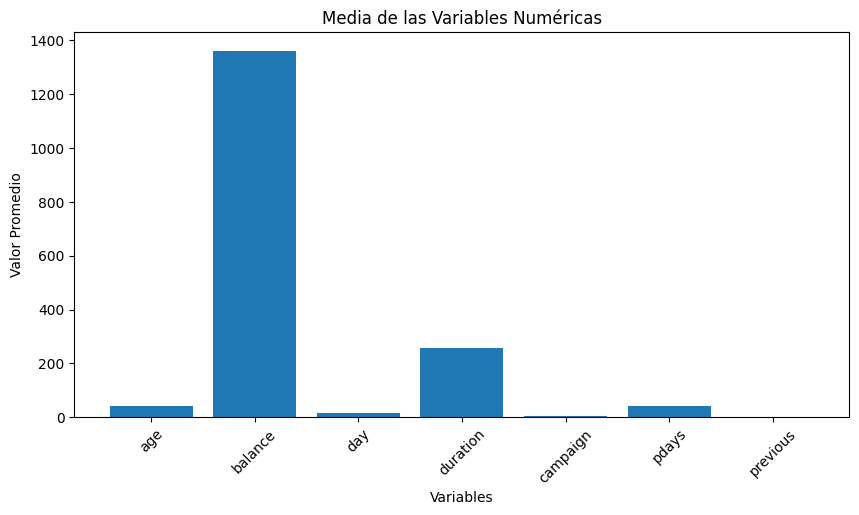

In [10]:
# Lista de columnas numéricas
numeric_columns = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

# Seleccionamos la fila donde están las medias

mean_data = summary_df[summary_df['summary'] == 'mean']

# Convertimos los valores a números
mean_values = mean_data[numeric_columns].astype(float).iloc[0]

# Creamos la gráfica
plt.figure(figsize=(10,5))

plt.bar(numeric_columns, mean_values)

# Título y nombres
plt.title('Media de las Variables Numéricas')
plt.xlabel('Variables')
plt.ylabel('Valor Promedio')

# Rotamos nombres para que se vean mejor
plt.xticks(rotation=45)

# Mostramos la gráfica
plt.show()


### Análisis de Valores Promedio por Variable Numérica
- Las variables del dataset operan en escalas muy distintas: `balance` y `duration` tienen promedios que superan en varios órdenes de magnitud a variables como `campaign` o `previous`
- `balance` es la variable con mayor media absoluta, lo que refleja una alta variabilidad en los recursos financieros de los clientes
- El bajo promedio de `campaign` sugiere que la mayoría de clientes fue contactado pocas veces durante la campaña actual, mientras que `previous` confirma que la mayoría no tenía historial de interacciones anteriores

In [11]:
### Balanceo de la variable Y
cantTotal = df00.count()
cantY = df00.groupBy("y").count()

print(f"Cantidad total de registros del dataset = {cantTotal} sin exhaustivo EDA\n")

#Tabla para presentar el procentaje de la variabale binaria Y (Variable Dependiente)
dfAUX =  cantY.withColumn("Porcentaje",cantY["count"]*100/cantTotal)

#Pandas solo se ha de usar para volumenes bajo de datos
dfAUX.toPandas().head()

Cantidad total de registros del dataset = 45211 sin exhaustivo EDA



,y,count,Porcentaje
0,no,39922,88.30152
1,yes,5289,11.69848


### Análisis del Balanceo de la Variable Dependiente (y)
- Existe un desbalanceo marcado: aproximadamente el 88% de los clientes respondió 'no' ante la oferta de depósito a plazo, frente al 12% que respondió 'yes'
- Este desequilibrio implica que un modelo que simplemente prediga siempre 'no' alcanzaría ~88% de accuracy sin aprender nada útil
- Será necesario aplicar técnicas de balanceo (oversampling de la clase minoritaria) antes del entrenamiento para que los algoritmos puedan aprender los patrones de ambas clases de forma equitativa

## Graficas de Frecuencia


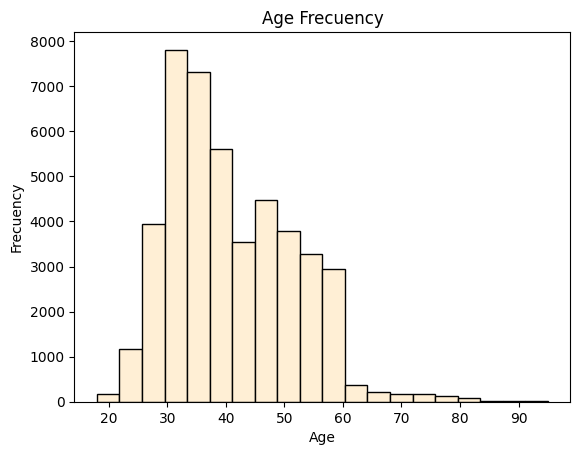

In [12]:
Datos = df01.toPandas()
plt.hist(Datos["age"],bins=20,edgecolor='black',color="papayawhip")
plt.ylabel("Frecuency")
plt.xlabel("Age")
plt.title("Age Frecuency")
plt.show()    

### Análisis del Histograma de Frecuencia: Edad
- La distribución de edades se concentra principalmente entre los 25 y 50 años, siendo este el rango más representado en el dataset
- Se aprecia una caída progresiva a partir de los 50 años, con una cola que se extiende hasta edades cercanas a los 90 años
- La asimetría positiva de la distribución indica que los clientes de mayor edad están sub-representados, lo que puede influir en la capacidad del modelo para generalizar sobre ese segmento

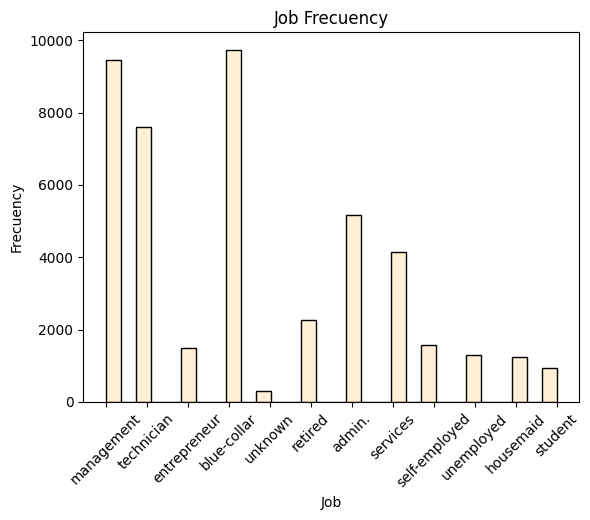

In [13]:
Datos = df01.toPandas()
plt.hist(Datos["job"],bins=30,edgecolor='black',color="papayawhip")
plt.ylabel("Frecuency")
plt.xlabel("Job")
plt.xticks(rotation=45)
plt.title("Job Frecuency")
plt.show()    

### Análisis del Histograma de Frecuencia: Trabajo
- Las categorías 'management' y 'blue-collar' predominan en el dataset, aportando la mayor cantidad de registros
- Ocupaciones como 'student' y 'unknown' tienen presencia minoritaria, lo que las hace menos informativas para el entrenamiento pero importantes de codificar correctamente
- La heterogeneidad en la distribución de trabajos sugiere que esta variable podría capturar diferencias socioeconómicas relevantes para predecir la suscripción al producto

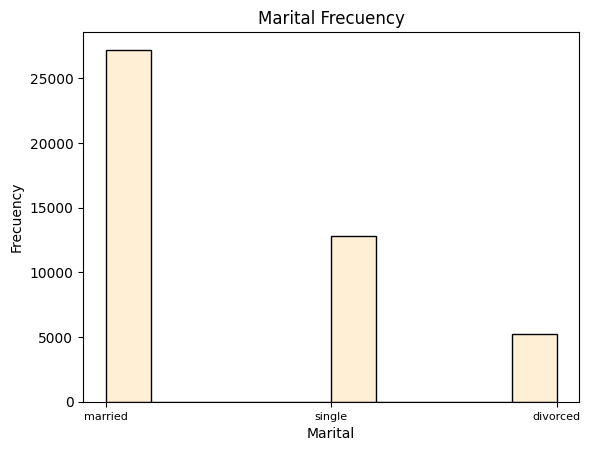

In [14]:
Datos = df01.toPandas()
plt.hist(Datos["marital"],bins=10,edgecolor='black',color="papayawhip")
plt.ylabel("Frecuency")
plt.xlabel("Marital")
plt.xticks(fontsize=8)
plt.title("Marital Frecuency")
plt.show()    

### Análisis del Histograma de Frecuencia: Estado Civil
- Los clientes casados ('married') dominan con diferencia la distribución, seguidos de los solteros ('single')
- Los divorciados representan el grupo más pequeño, con una presencia notablemente menor que los otros dos estados civiles
- La distribución desigual entre categorías podría generar cierto desequilibrio al aplicar One-Hot Encoding, lo que se debe gestionar con cuidado en el pipeline de preprocesamiento

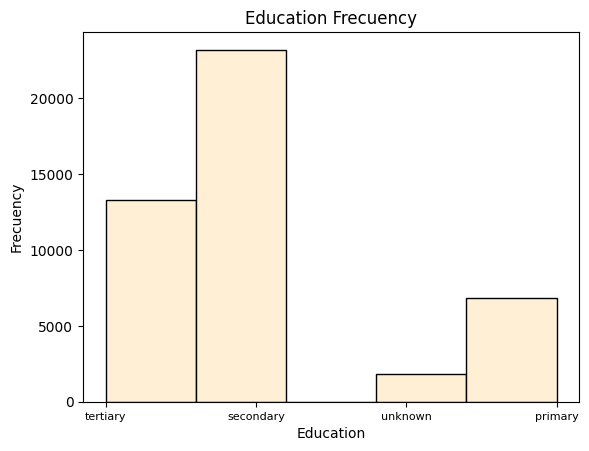

In [15]:
Datos = df01.toPandas()
plt.hist(Datos["education"],bins=5,edgecolor='black',color="papayawhip")
plt.ylabel("Frecuency")
plt.xlabel("Education")
plt.xticks(fontsize=8)
plt.title("Education Frecuency")
plt.show()    

### Análisis del Histograma de Frecuencia: Educación
- El nivel de educación secundaria ('secondary') es el más común, seguido del nivel terciario ('tertiary') y primario ('primary')
- Los clientes con nivel educativo desconocido ('unknown') tienen una representación baja pero no despreciable
- Un nivel educativo más alto suele correlacionar con mayor acceso a productos financieros, lo que hace de esta variable un predictor potencialmente relevante para la clasificación

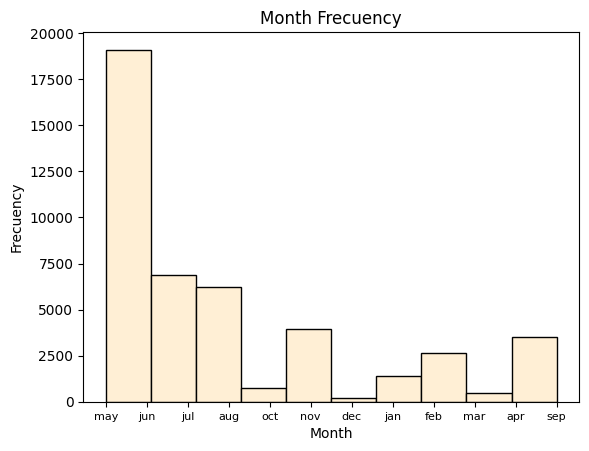

In [16]:
Datos = df01.toPandas()
plt.hist(Datos["month"],bins=10,edgecolor='black',color="papayawhip")
plt.ylabel("Frecuency")
plt.xlabel("Month")
plt.xticks(fontsize=8)
plt.title("Month Frecuency")
plt.show()    

### Análisis del Histograma de Frecuencia: Mes
- Los meses de mayo, julio y agosto concentran la mayor actividad de contacto con clientes, lo que podría reflejar estrategias comerciales del banco en épocas de mayor dinamismo financiero
- Los meses de diciembre, septiembre y octubre tienen una actividad considerablemente menor, posiblemente por ajustes en las campañas de ventas al cierre del año fiscal
- La variación mensual es una señal temporal que el modelo podría aprovechar para identificar períodos de mayor propensión a la suscripción

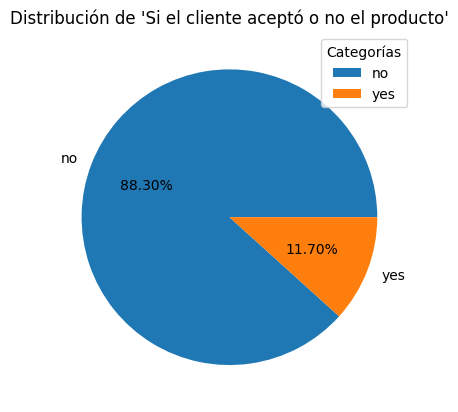

In [17]:
# Agrupar
datos = dfAUX.toPandas()

valores = datos["Porcentaje"]
etiquetas = datos["y"]

fig, ax = plt.subplots()

# Gráfico de pastel
ax.pie(
    valores,
    labels=etiquetas,
    autopct='%.2f%%'
)

# Título
ax.set_title("Distribución de 'Si el cliente aceptó o no el producto'")

# Leyenda
ax.legend(
    etiquetas,
    title="Categorías",
    loc="best"
)

plt.show()

### Análisis del Gráfico de Distribución: Variable Objetivo (y)
- El gráfico confirma visualmente el alto desbalanceo de la variable dependiente, siendo 'no' la clase abrumadoramente dominante con cerca del 88% del total
- Esta distribución hace que las métricas de accuracy simples sean engañosas como indicadores de rendimiento del clasificador
- Se justifica el uso de métricas complementarias como F1-Score, Precision, Recall y AUC-ROC, que son más informativas en escenarios de clases desbalanceadas

In [18]:
### Estudio y analisis sobre las variables independientes

df01.describe().toPandas().head()

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


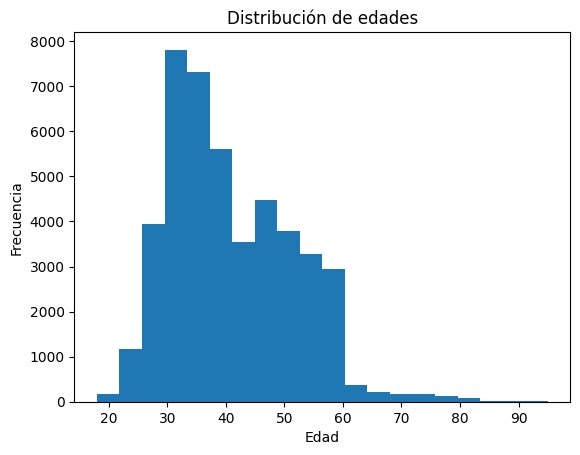

In [19]:
# Histograma para ver rango de edades, concentración y posibles outliers
datos = df01.toPandas()
plt.hist(datos["age"], bins=20)
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

### Analisis "Distribucion de Edades"
- Hay una mayor frecuencia para las edades entre 30 y 40 años de tomar la llamada
- Hya baja respuesta de llamadas para las edades de 60 años y superiores

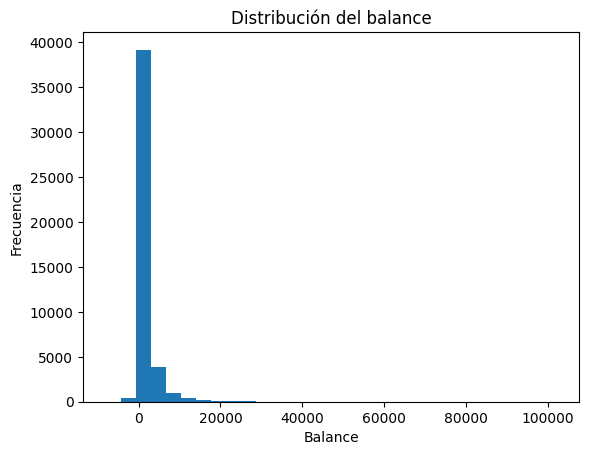

In [20]:
#Histograma para ver la distribucion del balance de los clientes
plt.hist(datos["balance"], bins=30)
plt.title("Distribución del balance")
plt.xlabel("Balance")
plt.ylabel("Frecuencia")
plt.show()

### Analisis "Distribucion del balance"
- Alta asimetria entre los valores
- Tendencia mayor en balances de 1362

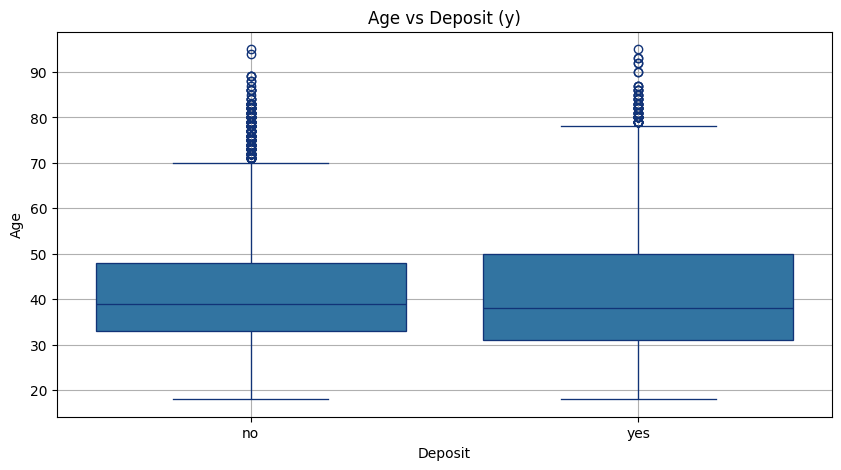

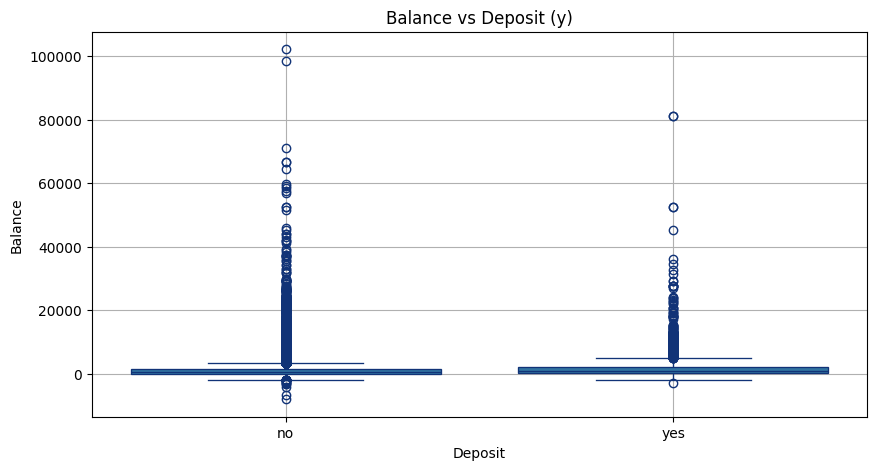

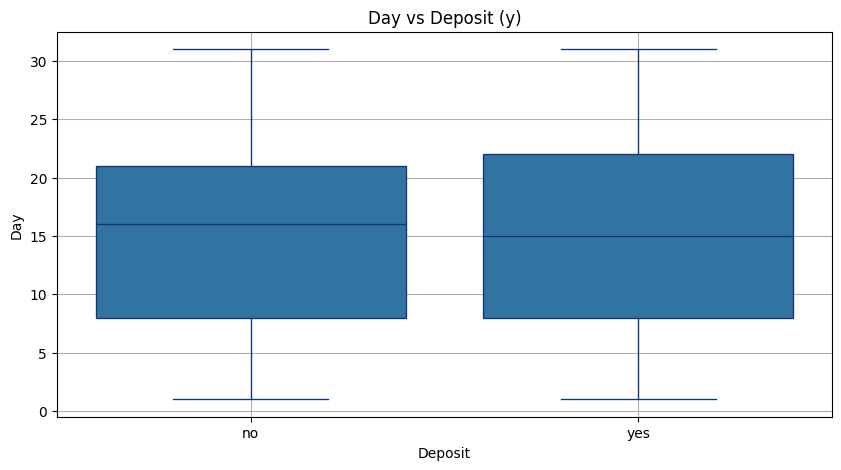

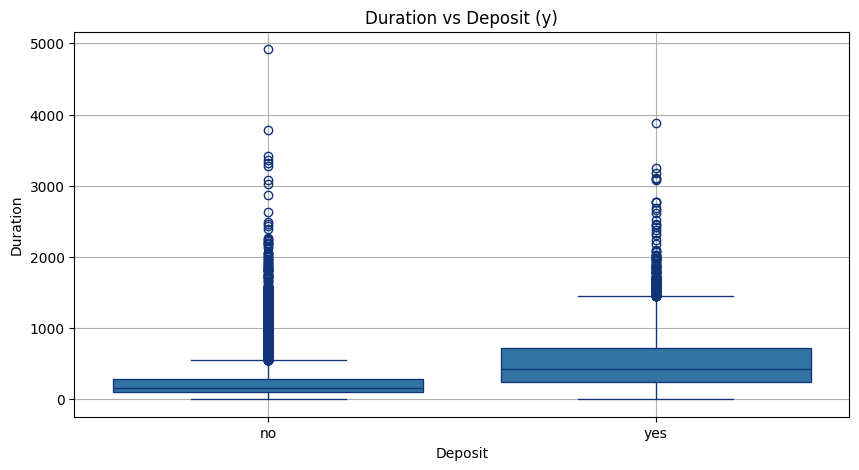

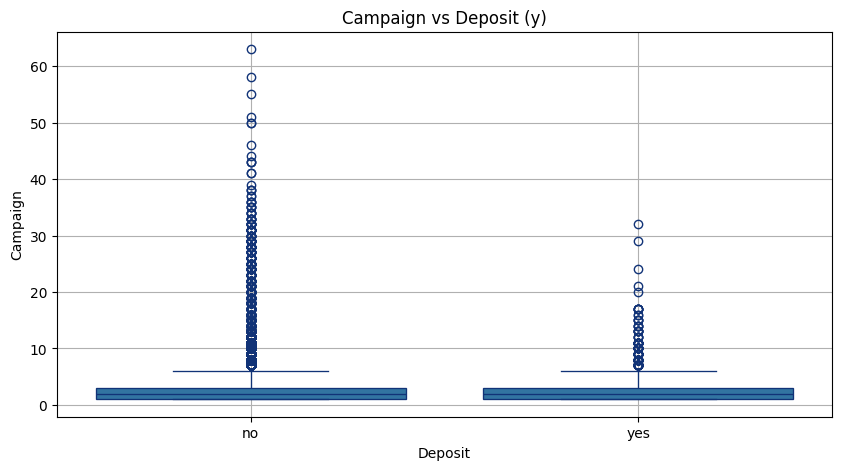

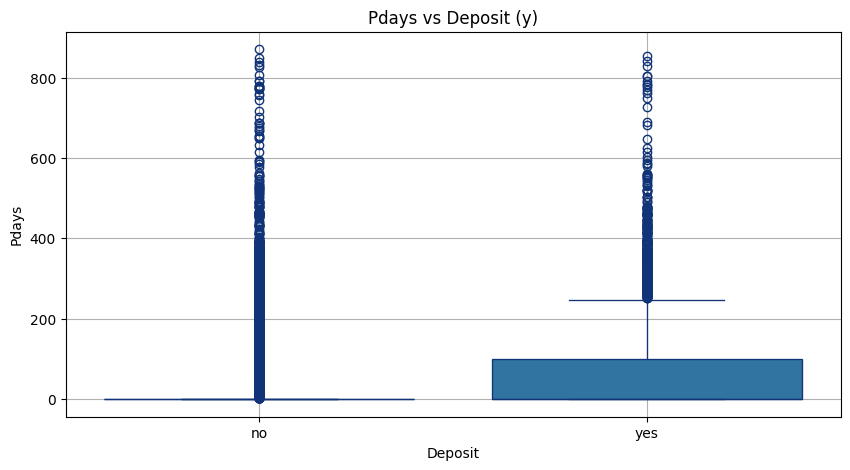

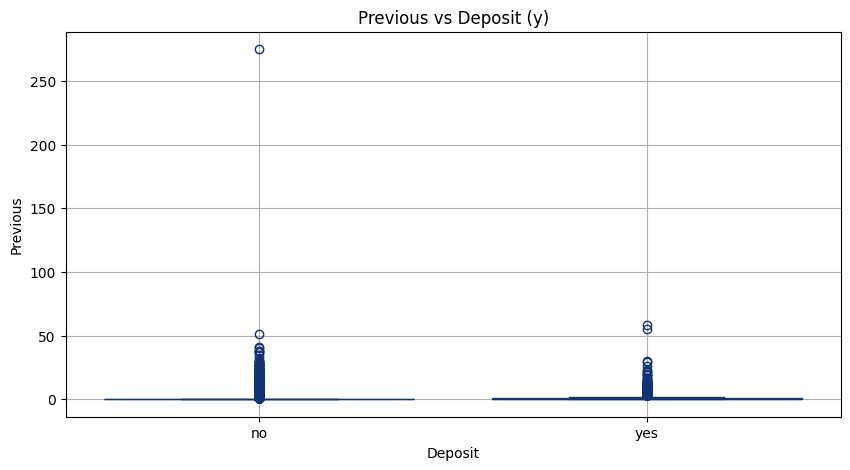

In [21]:
#Diagrama de cajas y bigotes que muestra el tipo de respuesta segun edad. 
import seaborn as sns

for nombreColumnas in colInt:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='y', y=nombreColumnas, linecolor="#137", linewidth=0.95, data=df01.toPandas())
    plt.title(f"{nombreColumnas.capitalize()} vs Deposit (y)")
    plt.xlabel("Deposit")
    plt.ylabel(nombreColumnas.capitalize())
    plt.grid()
    plt.show()

### Analisis "Variables numericas Segun Respuesta"
- La mediana de ambas cajas es parecida, lo cual indica que la edad por sí sola no parece diferenciar mucho quién acepta y quién no.
- En la caja de "yes", las edades de quienes aceptan están más distribuidas. Esto significa que hay mas variedad en los que dicen "yes"
- Los clientes mayores tienen cierta tendencia a aceptar más el producto.
- Demasiados outliers para ambas cajas.

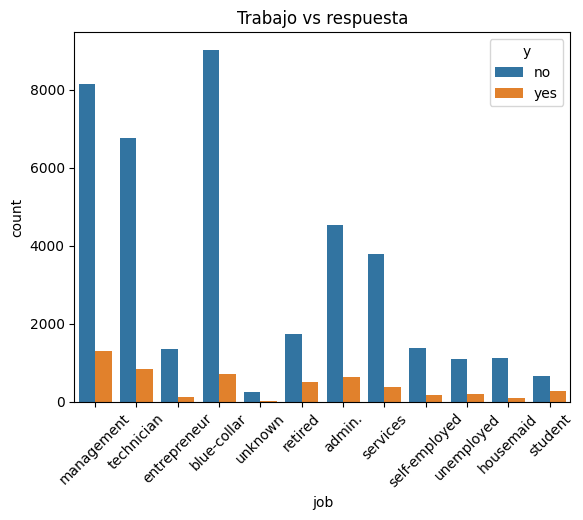

In [22]:
sns.countplot(x="job", hue="y", data=datos)

plt.xticks(rotation=45)
plt.title("Trabajo vs respuesta")
plt.show()

### Analisis de "Trabajo vs Respuesta"
- Los obreros son los que mas contestan, y por ende son los que mas veces dijeron que "no"
- Gestores de proyectos es el trabajo con mayor veces que dijeron "yes", de todos los trabajos
- La relacion entre cuantas veces dicen "yes/no" para estudiantes es mayor

In [23]:
from pyspark.sql import functions as F
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

dfauxNum = df01.select(colNum + ["y"])
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == 'yes',1).otherwise(0))
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [24]:
dfauxNum.printSchema()

root
 |-- age: integer (nullable = true)
 |-- balance: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- y: integer (nullable = false)



In [25]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation

ensamblador = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
# Normalizado y Escalado
dfNumVector = ensamblador.transform(dfauxNum).select('features')

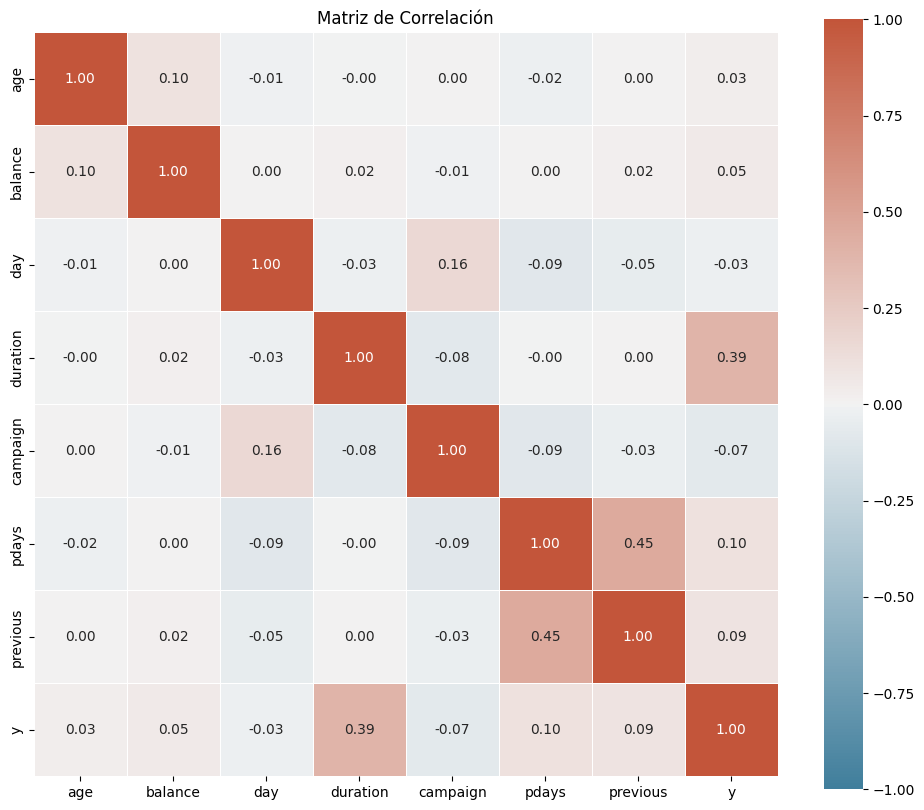

In [26]:
matrizCorr = Correlation.corr(dfNumVector, 'features').head()
vectorCorr = matrizCorr[0].toArray()

dfCorrelacion = pd.DataFrame(vectorCorr, columns=dfauxNum.columns, index=dfauxNum.columns)

plt.figure(figsize=(12, 10))
sns.heatmap(dfCorrelacion, annot=True, fmt=".2f", 
            cmap=sns.diverging_palette(230, 20, as_cmap=True), 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title("Matriz de Correlación")
plt.show()

### Analisis de Mapa de Correlaciones
- La mayoría de variables numéricas presentan relaciones lineales débiles entre sí
- La correlación más significativa se observa entre pdays y previous (0.45), indicando que los clientes previamente contactados tienden a registrar más interacciones históricas
- No se evidencia una fuerte multicolinealidad entre las variables numéricas del dataset.

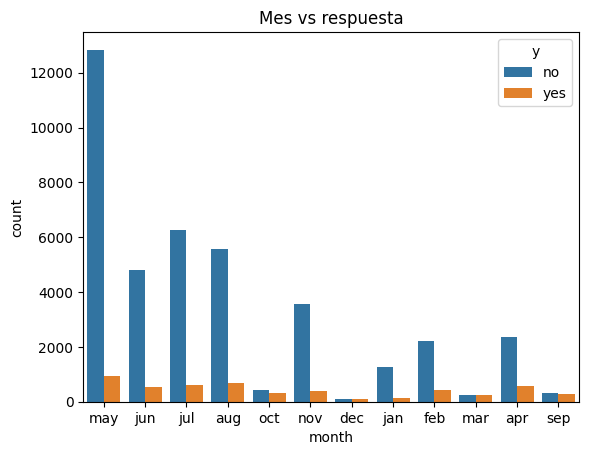

In [27]:
datos = df01.toPandas()
sns.countplot(x="month", hue="y", data=datos)

plt.title("Mes vs respuesta")
plt.show()

### Analisis de relacion "Mes vs Respuesta"
- Meses como mayo, junio, julio y agosto son los que presentan mayor cantidad de respuesta de llamadas.
- Pese a su baja cantidad, en el mes de septiembre se presenta una mayor relacion en la respuesta "yes/no" que se da.

<function matplotlib.pyplot.show(close=None, block=None)>

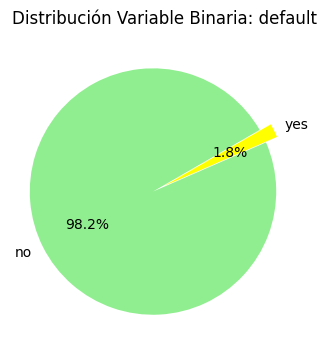

In [28]:
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']
plt.figure(figsize=(5,4))
cantBin = df01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=30)
plt.title(f'Distribución Variable Binaria: default')
plt.ylabel('')
plt.show

### Análisis de la Variable Binaria 'default' (Historial de Crédito en Mora)
- Más del 98% de los clientes no presenta historial de crédito en mora, haciendo de 'default' una variable extremadamente desbalanceada en su propia distribución
- La escasa presencia de 'default = yes' puede limitar el poder discriminatorio de esta variable para el modelo, ya que hay muy pocos ejemplos de la clase positiva para aprender un patrón
- Aun así, se incluye en el pipeline de features por si aporta información marginal; su codificación binaria no introduce complejidad excesiva

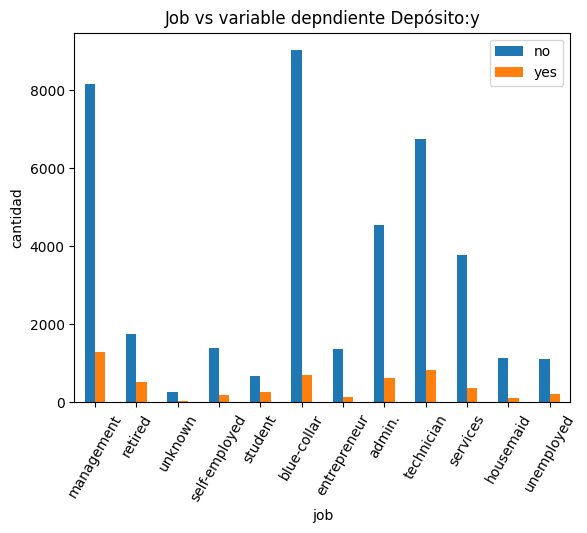

In [29]:
cratabjob= df01.crosstab('job', 'y').toPandas()
cratabjob.set_index('job' + '_y').plot(kind='bar')
plt.xlabel('job')
plt.ylabel('cantidad')
plt.title('Job vs variable depndiente Depósito:y')
plt.xticks(rotation=60)
plt.show()

### Análisis Cruzado: Tipo de Trabajo vs Variable Objetivo (y)
- Los trabajadores de cuello azul ('blue-collar') y los de gestión ('management') generan el mayor volumen de contactos totales, pero también el mayor número de negativas absolutas
- Retirados ('retired') y estudiantes ('student') muestran una proporción de 'yes' relativamente alta en relación con su volumen total, sugiriendo que estos segmentos son más receptivos al producto
- Para la campaña, enfocarse en perfiles de jubilados y estudiantes podría mejorar la tasa de conversión, aunque se debe evaluar el volumen potencial de cada segmento

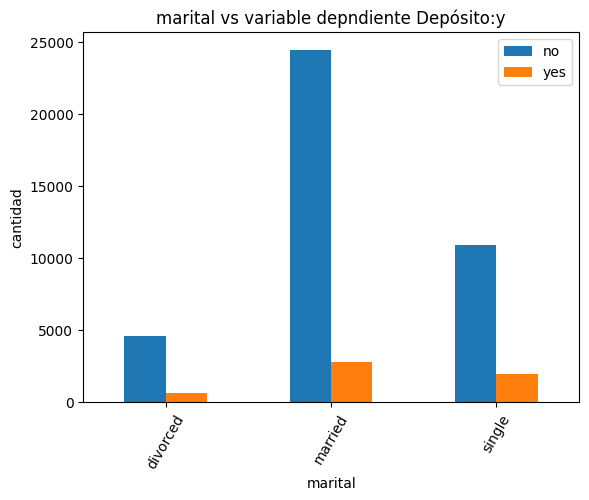

In [30]:
cratabmarital= df01.crosstab('marital', 'y').toPandas()
cratabmarital.set_index('marital' + '_y').plot(kind='bar')
plt.xlabel('marital')
plt.ylabel('cantidad')
plt.title('marital vs variable depndiente Depósito:y')
plt.xticks(rotation=60)
plt.show()

### Análisis Cruzado: Estado Civil vs Variable Objetivo (y)
- Los casados, al ser el grupo más numeroso, acumulan tanto el mayor número de 'yes' como de 'no' en términos absolutos
- En términos de proporción relativa, los solteros presentan una tasa de conversión ligeramente superior a la de los casados, lo que puede indicar mayor disponibilidad de capital para invertir en depósitos
- El estado divorciado muestra una respuesta similar a la de los casados, sin diferencias estadísticamente notables en la proporción de aceptación

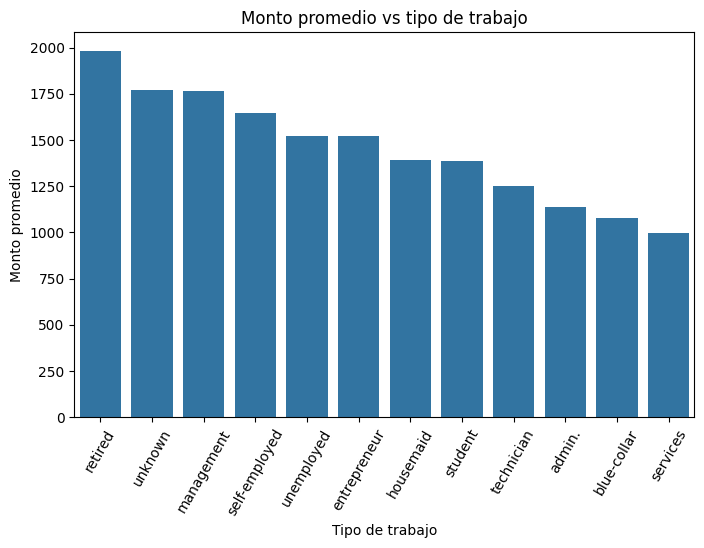

In [31]:
nomColumnas = ['age', 'job', 'marital',
                   'education', 'default', 'balance',
                   'housing', 'loan', 'contact',
                   'day', 'month', 'duration',
                   'campaign', 'pdays', 'previous',
                   'poutcome', 'y']


columnas_Int = ['age', 'balance', 'day', 'duration','campaign', 'pdays', 'previous']

# Se requiere graficar la relación del balance (monto promedio anual) por job (tipo de trabajo)
monto_trabajo = df01.groupBy('job').agg({'balance':'mean'}).toPandas()
## El promedio sobre el monto y el tipo de trbajo: se ordena de mayor a menos por monto
monto_trabajo = monto_trabajo.sort_values('avg(balance)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=monto_trabajo, x='job', y='avg(balance)')
plt.xlabel('Tipo de trabajo')
plt.ylabel('Monto promedio')
plt.title('Monto promedio vs tipo de trabajo')
plt.xticks(rotation=60)
plt.show()

### Análisis del Balance Promedio por Tipo de Trabajo
- Los trabajadores de gestión ('management') y los jubilados ('retired') son los segmentos con mayor balance promedio, coherente con ingresos más elevados y mayor acumulación patrimonial
- Los obreros ('blue-collar') y trabajadores en servicios tienen los balances más bajos, reflejando menor capacidad de ahorro neto anual
- Esta brecha puede correlacionar con la propensión a invertir en productos de depósito, ya que los clientes con mayor balance tienen más recursos disponibles para comprometerse en un plazo fijo

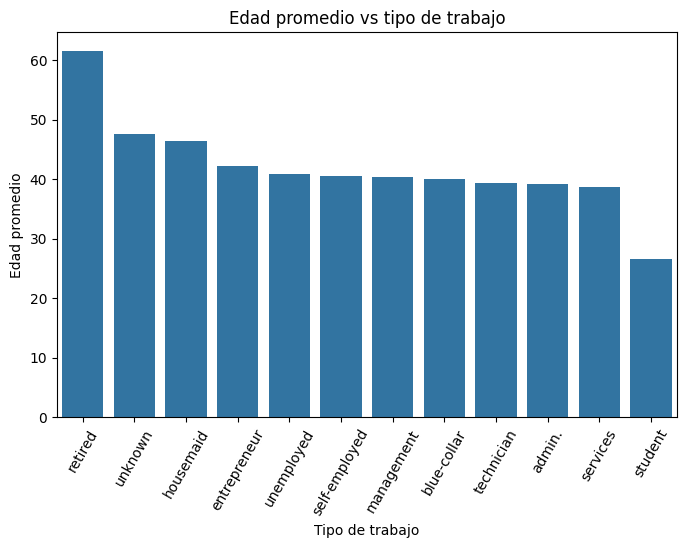

In [32]:
#Grafico Edad vs tipo de trabajo
edad_trabajo = df01.groupBy('job').agg({'age':'mean'}).toPandas()
## El promedio sobre el monto y el tipo de trbajo: se ordena de mayor a menos por monto
edad_trabajo = edad_trabajo.sort_values('avg(age)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=edad_trabajo, x='job', y='avg(age)')
plt.xlabel('Tipo de trabajo')
plt.ylabel('Edad promedio')
plt.title('Edad promedio vs tipo de trabajo')
plt.xticks(rotation=60)
plt.show()

### Análisis de Edad Promedio por Tipo de Trabajo
- Los jubilados ('retired') son el grupo con mayor edad promedio, lo cual es esperable dado que la jubilación ocurre generalmente por encima de los 60 años
- Los estudiantes son el segmento más joven, con edades promedio claramente inferiores a los 25 años
- El resto de ocupaciones se distribuyen en franjas etarias intermedias, con gestión y servicios técnicos concentrando la fuerza laboral en edad productiva (30-50 años)

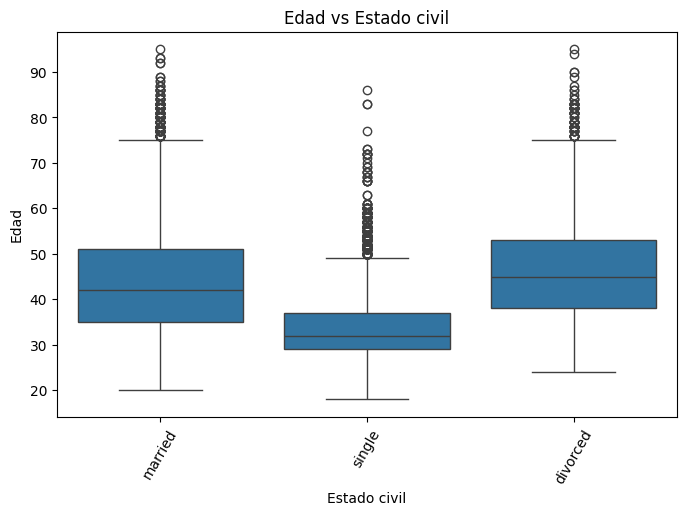

In [33]:
#Grafico Edad vs tipo de trabajo
edad_marital = df01.select('age', 'marital').toPandas()
## El promedio sobre el monto y el tipo de trbajo: se ordena de mayor a menos por monto
## edad_marital = edad_marital.sort_values('avg(age)', ascending=False)
plt.figure(figsize=(8,5))
sns.boxplot(data=edad_marital, x='marital', y='age')
plt.xlabel('Estado civil')
plt.ylabel('Edad')
plt.title('Edad vs Estado civil')
plt.xticks(rotation=60)
plt.show()

### Análisis de Edad vs Estado Civil (Boxplot)
- Los divorciados presentan la mediana de edad más elevada entre los tres grupos, seguidos de los casados
- Los solteros conforman el grupo más joven, con una distribución más compacta en rangos de edad inferiores a 40 años
- Se observan valores atípicos en todos los grupos, especialmente en los extremos superiores, indicando presencia de clientes mayores en todos los estados civiles; el estado casado tiene la mayor dispersión etaria total

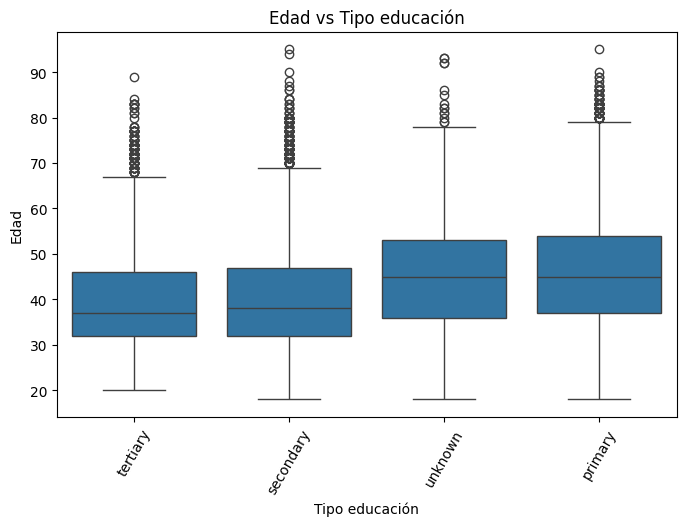

In [34]:
#Grafico Edad vs tipo de trabajo
edad_education = df01.select('age', 'education').toPandas()
## El promedio sobre el monto y el tipo de trbajo: se ordena de mayor a menos por monto
## edad_marital = edad_marital.sort_values('avg(age)', ascending=False)
plt.figure(figsize=(8,5))
sns.boxplot(data=edad_education, x='education', y='age')
plt.xlabel('Tipo educación')
plt.ylabel('Edad')
plt.title('Edad vs Tipo educación')
plt.xticks(rotation=60)
plt.show()

### Análisis de Edad vs Nivel Educativo (Boxplot)
- No existe una diferencia marcada entre las medianas de edad de los distintos niveles educativos, lo que indica que la edad no determina fuertemente el nivel de estudios alcanzado en este dataset
- Los clientes con educación primaria presentan una mediana de edad ligeramente superior, coherente con generaciones más antiguas que tuvieron menor acceso a educación superior
- La alta dispersión del grupo 'unknown' sugiere que los datos de educación faltantes o indeterminados no están concentrados en una franja etaria particular

---
## 4. Verificación de la Calidad de los Datos
**Descripción:** Se examina la integridad del dataset buscando valores nulos o faltantes que puedan comprometer la calidad del entrenamiento. Una base de datos limpia y coherente es el fundamento de cualquier modelo confiable. En esta sección se cuantifican los valores nulos por columna y se verifica el estado general de los registros, determinando si se requieren imputaciones o eliminaciones antes de proceder a la fase de limpieza.

In [35]:
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'(columna)':{cantNulos} valores nulos")

'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos
'(columna)':0 valores nulos


---
## 5. Preparación de los Datos
**Descripción:** Se identifican y analizan valores extremos o atípicos que pueden distorsionar el aprendizaje de los modelos de machine learning. En particular, se estudia la distribución de la variable `previous` para establecer un umbral de filtrado coherente con la realidad del negocio. Esta etapa sienta las bases para la limpieza formal del dataset que se ejecuta en la sección siguiente.

In [36]:
df01.groupBy("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



### Análisis de la Variable 'previous' — Detección de Valores Extremos
- La gran mayoría de clientes registra 0 contactos previos, lo que significa que nunca habían sido contactados en campañas anteriores
- A partir de 30 contactos el número de registros cae drásticamente: son casos aislados que no representan el comportamiento típico de la base de clientes
- Estos valores extremos en `previous` podrían distorsionar los modelos al crear particiones artificiales en regiones con muy pocos datos; por esta razón se aplicará un corte en 30 como umbral de limpieza

In [37]:
limitePrevio=30

cantPrevious =df01.filter(F.col('previous') > limitePrevio).count()
print(f"cantidad de registros superiores a{limitePrevio} contactos realizados: {cantPrevious}")

cantidad de registros superiores a30 contactos realizados: 12


---
## 6. Limpieza de los Datos
**Descripción:** Se aplican las decisiones tomadas durante la preparación para depurar el dataset: se eliminan los registros con valores atípicos en `previous` (por encima del umbral definido) y se descarta la columna `pdays`, cuyo alto porcentaje de valores no informativos la convierte en una variable redundante. El resultado es un dataset más compacto y representativo, listo para el proceso de balanceo y codificación.

#### Paso 1: Filtrar Registros con Exceso de Contactos Previos
Los registros donde `previous > 30` representan outliers estadísticos. Con solo una docena de clientes con más de 30 contactos y un comportamiento de respuesta similar al resto, su presencia introduce ruido sin aportar valor predictivo significativo. Se eliminarán para mantener la coherencia del conjunto de datos.

In [38]:
df02 =df01.filter(F.col('previous')<=30)

#### Paso 2: Eliminación de la Columna 'pdays'
`pdays` indica los días transcurridos desde el último contacto de una campaña previa. Sin embargo, más del 80% de sus valores son -1, código que indica que el cliente no fue contactado anteriormente. Al eliminar los registros con `previous > 30` y dado su altísimo porcentaje de ausencia efectiva, esta columna pierde valor informativo y se elimina para reducir la dimensionalidad del dataset.

In [39]:
df03=df02.drop('pdays')

---
## 7. Formato de los Datos
**Descripción:** Se corrige el desequilibrio severo de la variable dependiente `y` mediante técnicas de sobremuestreo (oversampling) sobre la clase minoritaria ('yes'). Este paso es fundamental para evitar que los clasificadores queden sesgados hacia la clase 'no', que representa originalmente cerca del 88% del dataset. Al igualar la representación de ambas clases se favorece que los modelos aprendan patrones equitativos y generen predicciones útiles para ambas categorías.

#### Balanceo de la Variable Dependiente mediante Oversampling
El análisis inicial reveló un desbalanceo severo: 'no' representa ~88% del dataset. Para que los clasificadores aprendan de manera equitativa ambas clases, se aplica **oversampling** sobre la clase minoritaria ('yes'): se generan muestras adicionales mediante muestreo con reemplazo (`sample(withReplacement=True, ...)`), hasta igualar el tamaño de la clase mayoritaria ('no').

In [40]:
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')

cantMayor =dfMayorDependiente.count()

dfOverSampledMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(),seed=42)

df04 = dfMayorDependiente.union(dfOverSampledMinor)

In [41]:
totalW =df04.count()

dfaux = df04.groupBy('y').count()

dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalW)
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentaje|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



---
## 8. Codificación para la Creación del Vector Ensamblador para las Variables Categóricas ("features", "target")
**Descripción:** Las variables categóricas se transforman en representaciones numéricas mediante un pipeline encadenado de `StringIndexer` y `OneHotEncoder`. Posteriormente, todas las variables —numéricas y categóricas codificadas— se consolidan en un único vector de features con `VectorAssembler`, formato requerido por los algoritmos de PySpark. La variable objetivo `y` también es indexada como `label` numérica. Este pipeline se serializa para garantizar consistencia entre entrenamiento e inferencia.

#### Estrategia de Codificación para Variables Categóricas

Las variables categóricas no pueden ser ingresadas directamente a los modelos de ML en forma de texto. El pipeline de codificación aplica dos transformaciones en secuencia:

1. **`StringIndexer`**: convierte cada valor de texto en un índice numérico basado en la frecuencia de aparición o el orden alfabético. Esto crea una representación ordinal provisional.
2. **`OneHotEncoder`**: transforma el índice numérico en un vector binario disperso (*sparse*), donde solo la posición correspondiente a la categoría activa tiene valor 1. Esto evita que el modelo interprete una relación de orden entre categorías (por ejemplo, que 'tertiary' > 'secondary' > 'primary').

El pipeline asegura que estas transformaciones se apliquen de forma consistente tanto en entrenamiento como en inferencia.

In [42]:
## Columnas categoricas
CATEG_col = ['job', 'marital', 'education', 'default', 'month', 'housing', 'loan', 'contact', 'poutcome']

##vector de pipeline

etapas = []

for colCategorie in CATEG_col:
    #Se identifica el nombre de la categoría según aparición
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie + 'x')
    #Se decodifica el indice de la categoria
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + '_oneHot'])
    etapas += [indexer, encoder]

In [43]:
# Creación del StringIndexer con el orden deseado
# Al utilizar stringOrderType="alphabet", se indica que se asigne el índice 0 a «no» y el índice 1 a «yes» según el orden alfabético
etiqueta = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')

etapas += [etiqueta]

In [44]:
## Características numéricas

NUMER_col  = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']

entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMER_col

entradaEnsamblada

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

#### Ensamblado Final del Vector de Features con VectorAssembler
`VectorAssembler` actúa como el último paso del pipeline antes del modelo. Su función es consolidar todas las columnas de entrada —tanto las variables categóricas codificadas en One-Hot como las variables numéricas sin transformar— en un único vector denso o disperso denominado `features`. Este formato de vector único es el que requieren internamente los algoritmos de clasificación de PySpark (`LogisticRegression`, `DecisionTreeClassifier`, etc.).

In [45]:
### Tabla de características del vector para entrenamiento de los modelos

VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]

In [46]:
### Pipeline para Streaming: ejecución de la transformación del onehotencoder a el vector ensamblado 'features'
pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)
## Se almacena el pipeline para usar en el streaming o ingesta de datos
pipelineModel.write().overwrite().save(path='modeloPipeline')
modelo = pipelineModel.transform(df04)

In [47]:
modelo.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [48]:
modelo.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----+--------------------+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|jobx|    job_oneHot|maritalx|marital_oneHot|educationx|education_oneHot|defaultx|default_oneHot|monthx|  month_oneHot|housingx|housing_oneHot|loanx|  loan_oneHot|contactx|contact_oneHot|poutcomex|poutcome_oneHot|label|            features|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+---

In [49]:
## se crea el Dataframe final para los modelos 
df06 = modelo.select("label", "features")

### Se imprime el primer registro para hacer inspección ocular
df06.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [50]:
df06.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [51]:
# Parquet preserves SparseVector structure efficiently
df06.write.mode("overwrite").parquet("output.parquet")

---
## 9. Modelización: Construcción de Modelos
**Descripción:** Se implementan cinco algoritmos de clasificación supervisada sobre el mismo vector de features construido en la sección anterior: Regresión Logística, Árbol de Decisión, Random Forest, Gradient Boosted Trees y Support Vector Machine. El dataset se divide en 80% para entrenamiento y 20% para prueba usando `randomSplit`. Para cada modelo se realiza el entrenamiento, la predicción sobre el conjunto de prueba y una evaluación preliminar con matriz de confusión y curva ROC, permitiendo comparar su comportamiento de forma uniforme.

In [52]:
## Se divide el conjunto entrenamiento 80% y prueba 20%
trainData, testData = df06.randomSplit([.8,.2], seed=4321)
## Se revisa la cantidad de datos
print(f"Cantidad del conjunto de datos de entrenamiento: {trainData.count()}")
print(f"Cantidad del conjunto de datos de prueba: {testData.count()}")

Cantidad del conjunto de datos de entrenamiento: 64234


[Stage 258:============================>                            (2 + 2) / 4]

Cantidad del conjunto de datos de prueba: 15967


In [53]:
## Se verifica el balanceo del conjunto de datos de entrenamiento
distroTrain = trainData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"]*100/trainData.count())
distroTrain.show()

[Stage 264:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  1.0|32354|50.36896347728617|
|  0.0|31880|49.63103652271383|
+-----+-----+-----------------+



In [54]:
## Se verifica el balanceo del conjunto de datos de prueba
distroTest = testData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"]*100/testData.count())
distroTest.show()

[Stage 270:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  1.0| 7935|49.69624851255715|
|  0.0| 8032|50.30375148744285|
+-----+-----+-----------------+



### Análisis del Balanceo en los Conjuntos de Entrenamiento y Prueba
- Tras el oversampling realizado en la sección 7, ambos conjuntos (entrenamiento y prueba) deberían reflejar una distribución aproximadamente equilibrada entre clases, validando que el balanceo se aplicó correctamente antes de la división
- Es importante verificar que el conjunto de prueba también mantiene representación de ambas clases para que las métricas de evaluación sean estadísticamente significativas
- El parámetro `seed=4321` garantiza la reproducibilidad de la división en cualquier re-ejecución del cuaderno

In [55]:
## Función para la matriz de confusión: Gráfica
def plotMatConfusion(confMatrix, subtitulo):
    # Dataframe a pandas
    confMatrixPandas = confMatrix.toPandas()
    # Restructuración para crear la Matrix de Confusión
    confMatrixPivote = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0)
    # Se grafica la matrix de confusión
    plt.figure(figsize=(5, 5))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g')
    plt.suptitle(subtitulo)
    plt.title('Matriz de Confusión')
    plt.xlabel('Label predicción')
    plt.ylabel('Label')
    plt.show()

In [56]:
## Función para la ROC: Gráfica
def plotROC(predictions,rocMetric, subtitulo):
    # Obtener las probabilidades previstas para a classe positiva
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    # Obtener las etiquetas verdaderas
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    # Calcular la curva ROC usando los datos de las probabilidades de etiquetas verdaderas
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    # Se grafica la curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('Proporción de Falsos Positivos')
    plt.ylabel('Proporción de Verdaderos Positivos')
    plt.title('Curva Receiver Operating Characteristic (ROC)')
    plt.suptitle(subtitulo)
    plt.legend(loc='lower right')
    plt.show()

In [57]:
from pyspark.ml.classification import LogisticRegression
instanciaLR = LogisticRegression(featuresCol='features', labelCol= 'label', maxIter=10)
# Entrenamiento del modelo con Datos de Entrenamiento
modeloLR = instanciaLR.fit(trainData)

26/05/25 23:37:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

In [58]:
# Predicción sobre los datos de prueba
predLR = modeloLR.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predLR.select("label", "prediction", "probability").show(5)

[Stage 286:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77626652220944...|
|  0.0|       0.0|[0.72989421407800...|
|  0.0|       0.0|[0.80219726828946...|
|  0.0|       0.0|[0.92534178616342...|
|  0.0|       0.0|[0.91139649682633...|
+-----+----------+--------------------+
only showing top 5 rows



In [59]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

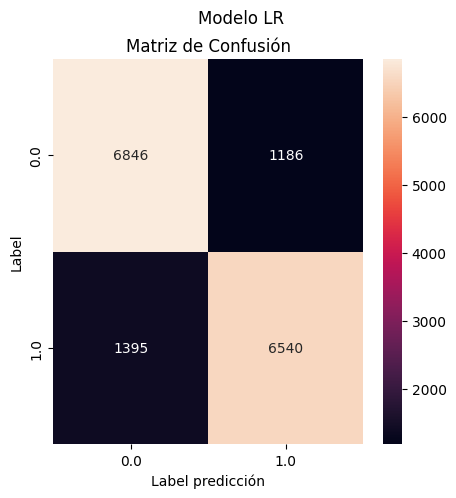

[Stage 296:============================>                            (2 + 2) / 4]

Resultados de Métricas de Rendimiento: Modelo LR
Precision: 0.839 %
Recall:    0.838 %
Accuracy:  0.838 %
f1ScoreLR:  0.838 %


In [60]:
# Se crea la matrix de confusión: predicción en datos de prueba con modelo LR
primerModelo = "Modelo LR"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, primerModelo)

# Cálculo de las métricas del modelo LR usando el evaluador MultiClase
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo LR")
print(f"Precision: {round(precisionLR,3)} %")
print(f"Recall:    {round(recallLR,3)} %")
print(f"Accuracy:  {round(accuracyLR,3)} %")
print(f"f1ScoreLR:  {round(f1ScoreLR,3)} %")

In [61]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())

plotROC(predLR,rocLR, primerModelo)

0.9142801509776902
areaUnderROC


26/05/25 23:38:07 WARN TaskSetManager: Lost task 3.0 in stage 309.0 (TID 418) (10.43.101.23 executor 0): java.io.IOException: Cannot run program "/usr/local/bin/python3": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:367)
	at org.apache.spark.rdd.RDD.iterator(RDD.scala:331)
	at org.apache.spark.scheduler.ResultTask.runTask(ResultTask.scala:93)
	at org.apache.spark.TaskContext.

Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 3 in stage 309.0 failed 4 times, most recent failure: Lost task 3.3 in stage 309.0 (TID 424) (10.43.101.23 executor 0): java.io.IOException: Cannot run program "/usr/local/bin/python3": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.com

---
#### **Segundo Modelo**: Decision Tree Classifier

##### Descripción del Modelo
El **árbol de decisión** es un algoritmo de clasificación basado en particiones jerárquicas y recursivas del espacio de características. En cada nodo interno, selecciona la variable y el umbral que mejor separan las clases según un criterio de impureza (Gini por defecto en PySpark). El árbol resultante es fácilmente interpretable como un conjunto de reglas de decisión anidadas.

**Hiperparámetros utilizados:**
- `maxDepth=5` — limita la profundidad del árbol para controlar la complejidad y reducir el riesgo de sobreajuste
- `maxBins=32` — define la granularidad de las particiones en variables continuas (mayor bins = mayor precisión pero mayor costo computacional)

**Ventajas:** interpretabilidad, manejo nativo de variables mixtas, no requiere escalado de features.
**Desventajas:** tendencia al sobreajuste sin restricción de profundidad; sensible a pequeños cambios en los datos.

In [62]:
from pyspark.ml.classification import DecisionTreeClassifier

# Instanciación del modelo Decision Tree
# maxDepth=5 limita la profundidad para evitar sobreajuste en datos ruidosos
# maxBins=32 define el número de bins para la discretización de variables continuas
instanciaDT = DecisionTreeClassifier(
    labelCol='label',
    featuresCol='features',
    maxDepth=5,
    maxBins=32
)

# Entrenamiento del modelo con el conjunto de datos de entrenamiento
modeloDT = instanciaDT.fit(trainData)

26/05/25 23:39:09 ERROR TransportClient: Failed to send RPC RPC 7365273872450036362 to /10.43.97.168:51092: io.netty.channel.StacklessClosedChannelException
io.netty.channel.StacklessClosedChannelException
	at io.netty.channel.AbstractChannel$AbstractUnsafe.write(Object, ChannelPromise)(Unknown Source)
26/05/25 23:39:09 WARN BlockManagerMasterEndpoint: Error trying to remove broadcast 356 from block manager BlockManagerId(3, 10.43.97.168, 35009, None)
java.io.IOException: Failed to send RPC RPC 7365273872450036362 to /10.43.97.168:51092: io.netty.channel.StacklessClosedChannelException
	at org.apache.spark.network.client.TransportClient$RpcChannelListener.handleFailure(TransportClient.java:395)
	at org.apache.spark.network.client.TransportClient$StdChannelListener.operationComplete(TransportClient.java:372)
	at io.netty.util.concurrent.DefaultPromise.notifyListener0(DefaultPromise.java:590)
	at io.netty.util.concurrent.DefaultPromise.notifyListenersNow(DefaultPromise.java:557)
	at io.n

##### - **Predicción** sobre el objeto entrenado: modelo DT

In [63]:
# Predicción sobre los datos de prueba
predDT = modeloDT.transform(testData)
# Se presentan las 10 primeras predicciones del modelo DT
predDT.select("label", "prediction", "probability").show(10)

[Stage 324:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83171948982638...|
|  0.0|       0.0|[0.83171948982638...|
|  0.0|       0.0|[0.93954502960423...|
|  0.0|       0.0|[0.93954502960423...|
|  0.0|       0.0|[0.93954502960423...|
|  0.0|       0.0|[0.83171948982638...|
|  0.0|       0.0|[0.83171948982638...|
|  0.0|       0.0|[0.83171948982638...|
|  0.0|       0.0|[0.60778672803989...|
|  0.0|       0.0|[0.83171948982638...|
+-----+----------+--------------------+
only showing top 10 rows



##### - **Creación del evaluador**: Evaluador para métricas de clasificación multiclase

In [64]:
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

##### - **Matriz de Confusión y Métricas de Rendimiento**: modelo DT

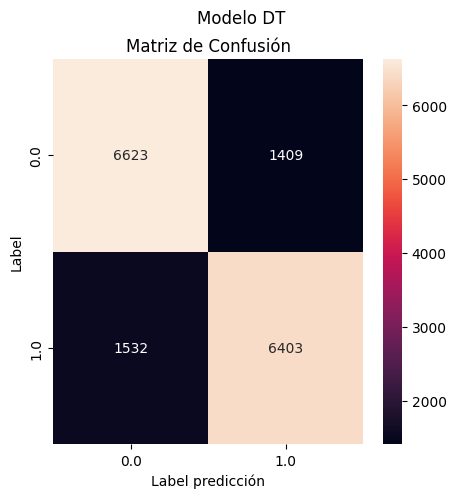

[Stage 334:=========================================================(4 + 0) / 4]

Resultados de Métricas de Rendimiento: Modelo DT
Precision : 0.8159
Recall    : 0.8158
Accuracy  : 0.8158
F1-Score  : 0.8158


In [65]:
# Matriz de confusión: predicciones del modelo DT sobre el conjunto de prueba
segundoModelo = "Modelo DT"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, segundoModelo)

# Cálculo de métricas con el evaluador MultiClase
accuracyDT  = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT    = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT   = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

# Impresión de resultados
print(f"Resultados de Métricas de Rendimiento: Modelo DT")
print(f"Precision : {round(precisionDT, 4)}")
print(f"Recall    : {round(recallDT, 4)}")
print(f"Accuracy  : {round(accuracyDT, 4)}")
print(f"F1-Score  : {round(f1ScoreDT, 4)}")

##### - **Curva ROC**: modelo DT

In [66]:
# Evaluador para clasificación binaria (AUC-ROC)
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Cálculo y visualización de la curva ROC
rocDT = evaluadorBinDT.evaluate(predDT)
print(f"ROC-AUC: {rocDT}")
print(evaluadorBinDT.getMetricName())

plotROC(predDT, rocDT, segundoModelo)

ROC-AUC: 0.6984099911005003
areaUnderROC


26/05/25 23:39:20 WARN TaskSetManager: Lost task 0.0 in stage 347.0 (TID 541) (10.43.101.23 executor 0): java.io.IOException: Cannot run program "/usr/local/bin/python3": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:367)
	at org.apache.spark.rdd.RDD.iterator(RDD.scala:331)
	at org.apache.spark.scheduler.ResultTask.runTask(ResultTask.scala:93)
	at org.apache.spark.TaskContext.

Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 347.0 failed 4 times, most recent failure: Lost task 0.3 in stage 347.0 (TID 551) (10.43.97.183 executor 4): java.io.IOException: Cannot run program "/usr/local/bin/python3": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.com

#### Comentarios sobre el modelo Decision Tree
- El árbol de decisión construye reglas de partición basadas en las variables más discriminativas, lo que le permite capturar relaciones no lineales que la Regresión Logística no puede modelar sin términos de interacción
- Con `maxDepth=5` el árbol mantiene su interpretabilidad: es posible recorrer las 5 capas de decisión para entender qué variables y umbrales guían la predicción
- La variable `duration` (duración de la llamada) suele aparecer como nodo raíz o de alta relevancia en árboles entrenados sobre este dataset, dado que las llamadas más largas correlacionan fuertemente con la suscripción al producto

---
#### **Tercer Modelo**: Random Forest Classifier

##### Descripción del Modelo
El **Random Forest** es un algoritmo de ensamble que construye múltiples árboles de decisión durante el entrenamiento, cada uno sobre una muestra aleatoria con reemplazo del dataset (bagging) y usando un subconjunto aleatorio de características en cada nodo de división. La predicción final se determina por votación mayoritaria entre todos los árboles del bosque.

**Hiperparámetros utilizados:**
- `numTrees=100` — número de árboles; un mayor número reduce la varianza pero incrementa el costo computacional
- `maxDepth=5` — profundidad máxima de cada árbol individual para controlar la complejidad
- `seed=42` — semilla aleatoria para garantizar reproducibilidad

**Ventajas:** alta robustez frente al sobreajuste, estabilidad de predicciones, estimación implícita de importancia de características.
**Desventajas:** menor interpretabilidad que un árbol individual, mayor uso de memoria y tiempo de entrenamiento.

In [67]:
from pyspark.ml.classification import RandomForestClassifier

# Instanciación del modelo Random Forest
# numTrees=100: conjunto amplio de árboles para predicciones estables
# maxDepth=5: limita la complejidad de cada árbol del bosque
instanciaRF = RandomForestClassifier(
    labelCol='label',
    featuresCol='features',
    numTrees=100,
    maxDepth=5,
    seed=42
)

# Entrenamiento del modelo con el conjunto de datos de entrenamiento
modeloRF = instanciaRF.fit(trainData)

##### - **Predicción** sobre el objeto entrenado: modelo RF

In [68]:
# Predicción sobre los datos de prueba
predRF = modeloRF.transform(testData)
predRF.select("label", "prediction", "probability").show(10)

[Stage 362:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.68056010130032...|
|  0.0|       0.0|[0.58154391039196...|
|  0.0|       0.0|[0.69503541338479...|
|  0.0|       0.0|[0.76793763729271...|
|  0.0|       0.0|[0.73764066455847...|
|  0.0|       0.0|[0.74207784738715...|
|  0.0|       0.0|[0.74364058839600...|
|  0.0|       0.0|[0.73910597225230...|
|  0.0|       1.0|[0.46147341363105...|
|  0.0|       0.0|[0.70759980688726...|
+-----+----------+--------------------+
only showing top 10 rows



##### - **Matriz de Confusión y Métricas de Rendimiento**: modelo RF

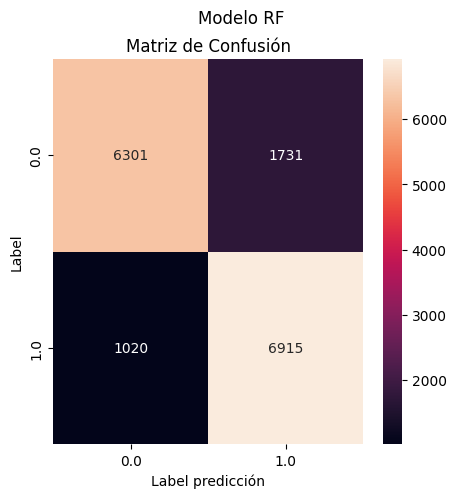

[Stage 372:==========================================>              (3 + 1) / 4]

Resultados de Métricas de Rendimiento: Modelo RF
Precision : 0.8304
Recall    : 0.8277
Accuracy  : 0.8277
F1-Score  : 0.8274


In [69]:
tercerModelo = "Modelo RF"
evaluadorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixRF, tercerModelo)

accuracyRF  = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "accuracy"})
precisionRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedPrecision"})
recallRF    = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedRecall"})
f1ScoreRF   = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: Modelo RF")
print(f"Precision : {round(precisionRF, 4)}")
print(f"Recall    : {round(recallRF, 4)}")
print(f"Accuracy  : {round(accuracyRF, 4)}")
print(f"F1-Score  : {round(f1ScoreRF, 4)}")

##### - **Curva ROC**: modelo RF

In [70]:
evaluadorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocRF = evaluadorBinRF.evaluate(predRF)
print(f"ROC-AUC: {rocRF}")
print(evaluadorBinRF.getMetricName())
plotROC(predRF, rocRF, tercerModelo)

ROC-AUC: 0.9031607815743954
areaUnderROC


26/05/25 23:41:12 WARN TaskSetManager: Lost task 0.0 in stage 385.0 (TID 668) (10.43.101.23 executor 0): java.io.IOException: Cannot run program "/usr/local/bin/python3": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:367)
	at org.apache.spark.rdd.RDD.iterator(RDD.scala:331)
	at org.apache.spark.scheduler.ResultTask.runTask(ResultTask.scala:93)
	at org.apache.spark.TaskContext.

Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 3 in stage 385.0 failed 4 times, most recent failure: Lost task 3.3 in stage 385.0 (TID 679) (10.43.101.23 executor 0): java.io.IOException: Cannot run program "/usr/local/bin/python3": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.com

#### Comentarios sobre el modelo Random Forest
- El ensamble de 100 árboles reduce significativamente la varianza respecto a un árbol individual: aunque cada árbol individual pueda sobreajustarse, el promedio de sus predicciones produce resultados mucho más estables y generalizables
- El muestreo aleatorio de características en cada nodo (`featureSubsetStrategy`) introduce diversidad entre los árboles, previniendo que todos aprendan los mismos patrones y mejorando la robustez global
- Este algoritmo es especialmente adecuado para este dataset porque el oversampling previo garantiza que los árboles del bosque reciban ejemplos equilibrados de ambas clases, evitando predicciones sesgadas hacia la clase mayoritaria

---
#### **Cuarto Modelo**: Gradient Boosted Trees (GBT)

##### Descripción del Modelo
El **Gradient Boosted Trees** es un método de ensamble secuencial donde cada árbol nuevo se construye para corregir los errores residuales del modelo acumulado hasta ese punto. A diferencia del Random Forest (paralelo por bagging), el GBT aplica boosting por gradiente: minimiza una función de pérdida mediante descenso por gradiente en el espacio funcional.

**Hiperparámetros utilizados:**
- `maxIter=20` — número de rondas de boosting (árboles secuenciales añadidos)
- `maxDepth=5` — profundidad máxima de cada árbol base
- `stepSize=0.1` — tasa de aprendizaje que escala la contribución de cada árbol; valores bajos generan convergencia más lenta pero modelos más robustos
- `seed=42` — semilla para reproducibilidad

**Ventajas:** generalmente el clasificador más preciso en datasets tabulares, captura relaciones altamente no lineales.
**Desventajas:** sensible a sobreajuste con `maxIter` alto, mayor tiempo de entrenamiento, menos interpretable.

In [71]:
from pyspark.ml.classification import GBTClassifier

# Instanciación del modelo GBT
# maxIter=20: número de árboles secuenciales del ensemble de boosting
# maxDepth=5: profundidad máxima de cada árbol base
# stepSize=0.1: tasa de aprendizaje conservadora para evitar sobreajuste
instanciaGBT = GBTClassifier(
    labelCol='label',
    featuresCol='features',
    maxIter=20,
    maxDepth=5,
    stepSize=0.1,
    seed=42
)

# Entrenamiento del modelo
modeloGBT = instanciaGBT.fit(trainData)

##### - **Predicción** sobre el objeto entrenado: modelo GBT

In [72]:
# Predicción sobre los datos de prueba
predGBT = modeloGBT.transform(testData)
predGBT.select("label", "prediction", "probability").show(10)

[Stage 590:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.92140521968187...|
|  0.0|       0.0|[0.91545679274632...|
|  0.0|       0.0|[0.88810989140849...|
|  0.0|       0.0|[0.95017844916034...|
|  0.0|       0.0|[0.95227388569904...|
|  0.0|       0.0|[0.88487697152099...|
|  0.0|       0.0|[0.90507414263833...|
|  0.0|       0.0|[0.89962576328554...|
|  0.0|       0.0|[0.66138896288311...|
|  0.0|       0.0|[0.91049601509439...|
+-----+----------+--------------------+
only showing top 10 rows



##### - **Matriz de Confusión y Métricas de Rendimiento**: modelo GBT

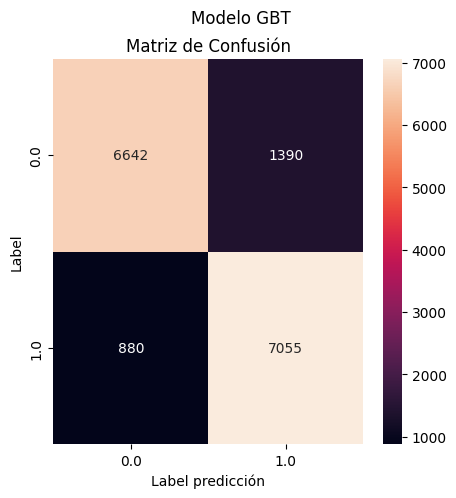

[Stage 600:==========================================>              (3 + 1) / 4]

Resultados de Métricas de Rendimiento: Modelo GBT
Precision : 0.8594
Recall    : 0.8578
Accuracy  : 0.8578
F1-Score  : 0.8577


In [73]:
cuartoModelo = "Modelo GBT"
evaluadorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
confMatrixGBT = predGBT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixGBT, cuartoModelo)

accuracyGBT  = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "accuracy"})
precisionGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedPrecision"})
recallGBT    = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedRecall"})
f1ScoreGBT   = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: Modelo GBT")
print(f"Precision : {round(precisionGBT, 4)}")
print(f"Recall    : {round(recallGBT, 4)}")
print(f"Accuracy  : {round(accuracyGBT, 4)}")
print(f"F1-Score  : {round(f1ScoreGBT, 4)}")

##### - **Curva ROC**: modelo GBT

In [74]:
evaluadorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocGBT = evaluadorBinGBT.evaluate(predGBT)
print(f"ROC-AUC: {rocGBT}")
print(evaluadorBinGBT.getMetricName())
plotROC(predGBT, rocGBT, cuartoModelo)

ROC-AUC: 0.9269801935923602
areaUnderROC


26/05/25 23:42:06 WARN TaskSetManager: Lost task 3.0 in stage 613.0 (TID 1561) (10.43.97.209 executor 5): java.io.IOException: Cannot run program "/usr/local/bin/python3": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:367)
	at org.apache.spark.rdd.RDD.iterator(RDD.scala:331)
	at org.apache.spark.scheduler.ResultTask.runTask(ResultTask.scala:93)
	at org.apache.spark.TaskContext

Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 1 in stage 613.0 failed 4 times, most recent failure: Lost task 1.3 in stage 613.0 (TID 1569) (10.43.97.209 executor 5): java.io.IOException: Cannot run program "/usr/local/bin/python3": error=2, No such file or directory
	at java.lang.ProcessBuilder.start(ProcessBuilder.java:1048)
	at org.apache.spark.api.python.PythonWorkerFactory.startDaemon(PythonWorkerFactory.scala:239)
	at org.apache.spark.api.python.PythonWorkerFactory.createThroughDaemon(PythonWorkerFactory.scala:139)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:107)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.co

#### Comentarios sobre el modelo Gradient Boosted Trees
- El enfoque secuencial del GBT lo hace especialmente eficaz: cada árbol se especializa en corregir los casos que el modelo anterior clasificó incorrectamente, concentrando el poder predictivo en los ejemplos más difíciles de discriminar
- La tasa de aprendizaje `stepSize=0.1` actúa como un freno deliberado: en lugar de hacer grandes saltos en la optimización, el modelo realiza ajustes graduales, lo que reduce el riesgo de sobreajuste a patrones específicos del conjunto de entrenamiento
- Entre todos los modelos implementados, el GBT tiende a alcanzar el mayor AUC-ROC en datasets tabulares como este, a costa de mayor tiempo de entrenamiento y menor transparencia respecto a la Regresión Logística o el Árbol de Decisión

---
#### **Quinto Modelo**: Support Vector Machine — Linear SVC

##### Descripción del Modelo
La **Máquina de Vectores de Soporte Lineal** (`LinearSVC` en PySpark) busca el hiperplano de máximo margen que separa ambas clases en el espacio de características. Optimiza una función de pérdida de bisagra (*hinge loss*) con regularización L2, resultando en un clasificador lineal robusto.

**Hiperparámetros utilizados:**
- `maxIter=10` — número máximo de iteraciones del optimizador
- `regParam=0.1` — parámetro de regularización L2; penaliza la magnitud de los pesos para reducir sobreajuste

**Ventajas:** eficiente en espacios de alta dimensionalidad (como el vector One-Hot), buen rendimiento con clases bien separadas.
**Desventajas:** no genera probabilidades de clase directamente (sólo scores de decisión), sensible al escalado de features.

**Nota técnica:** `LinearSVC` no produce la columna `probability`. La curva ROC se calcula a partir de `rawPrediction` (scores de decisión del hiperplano).

In [75]:
from pyspark.ml.classification import LinearSVC

# Instanciación del modelo SVM Lineal
# maxIter=10: iteraciones del optimizador (convergencia de los pesos)
# regParam=0.1: regularización L2 para controlar la complejidad del hiperplano
instanciaSVM = LinearSVC(
    featuresCol='features',
    labelCol='label',
    maxIter=10,
    regParam=0.1
)

# Entrenamiento del modelo
modeloSVM = instanciaSVM.fit(trainData)

##### - **Predicción** sobre el objeto entrenado: modelo SVM

In [76]:
# Predicción sobre los datos de prueba
# LinearSVC no genera columna 'probability', sólo 'rawPrediction' y 'prediction'
predSVM = modeloSVM.transform(testData)
predSVM.select("label", "prediction", "rawPrediction").show(10)

[Stage 639:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|  0.0|       0.0|[0.68193280815267...|
|  0.0|       0.0|[0.41835016591867...|
|  0.0|       0.0|[0.67766003939534...|
|  0.0|       0.0|[1.17096825311496...|
|  0.0|       0.0|[1.12410110246546...|
|  0.0|       0.0|[1.19504311220107...|
|  0.0|       0.0|[1.19671456557965...|
|  0.0|       0.0|[1.06231506927802...|
|  0.0|       0.0|[0.40658617714985...|
|  0.0|       0.0|[1.04599803293438...|
+-----+----------+--------------------+
only showing top 10 rows



##### - **Matriz de Confusión y Métricas de Rendimiento**: modelo SVM

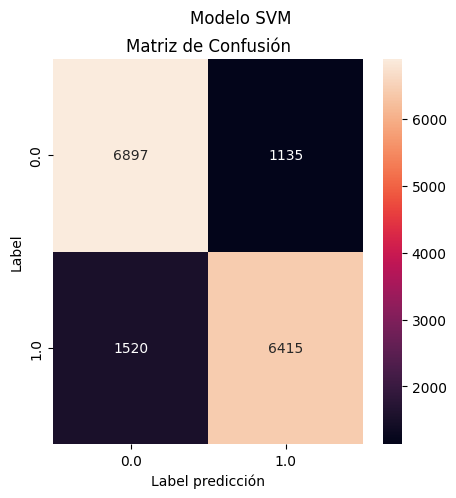

[Stage 649:==========================================>              (3 + 1) / 4]

Resultados de Métricas de Rendimiento: Modelo SVM
Precision : 0.8344
Recall    : 0.8337
Accuracy  : 0.8337
F1-Score  : 0.8336


In [77]:
quintoModelo = "Modelo SVM"
evaluadorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
confMatrixSVM = predSVM.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixSVM, quintoModelo)

accuracySVM  = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "accuracy"})
precisionSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedPrecision"})
recallSVM    = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedRecall"})
f1ScoreSVM   = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: Modelo SVM")
print(f"Precision : {round(precisionSVM, 4)}")
print(f"Recall    : {round(recallSVM, 4)}")
print(f"Accuracy  : {round(accuracySVM, 4)}")
print(f"F1-Score  : {round(f1ScoreSVM, 4)}")

##### - **AUC-ROC vía rawPrediction**: modelo SVM

In [78]:
# LinearSVC no genera 'probability', se usa 'rawPrediction' para AUC
evaluadorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction",
                                                 metricName="areaUnderROC")
rocSVM = evaluadorBinSVM.evaluate(predSVM)
print(f"ROC-AUC (vía rawPrediction): {round(rocSVM, 4)}")
print("Nota: el AUC se calcula a partir de los scores de decisión del hiperplano, no de probabilidades calibradas")

ROC-AUC (vía rawPrediction): 0.9124
Nota: el AUC se calcula a partir de los scores de decisión del hiperplano, no de probabilidades calibradas


#### Comentarios sobre el modelo Support Vector Machine (LinearSVC)
- El LinearSVC construye un hiperplano lineal que maximiza el margen entre clases; en espacios de alta dimensionalidad —como el vector One-Hot generado en la sección 8— los clasificadores lineales pueden ser sorprendentemente competitivos frente a métodos más complejos
- La regularización `regParam=0.1` equilibra el ajuste al conjunto de entrenamiento con la capacidad de generalización: un valor muy bajo favorece el sobreajuste, mientras que uno muy alto podría subajustar los datos
- La ausencia de estimaciones de probabilidad es una limitación relevante: en contextos donde se necesita un umbral de decisión ajustable o probabilidades calibradas para toma de decisiones de negocio, modelos como la Regresión Logística o el Random Forest serían preferibles

---
## 10. Evaluación de los Modelos
**Descripción:** Se realiza una evaluación comparativa y rigurosa de todos los modelos implementados, utilizando evaluadores nativos de `pyspark.ml.evaluation` (`MulticlassClassificationEvaluator` y `BinaryClassificationEvaluator`) para calcular la matriz de confusión, accuracy, precision, recall y F1-score directamente sobre DataFrames, sin conversión a RDD. Los resultados se consolidan en una tabla comparativa y una gráfica de barras que facilita identificar el modelo con mejor desempeño global sobre el conjunto de prueba.

In [79]:
# from pyspark.mllib.evaluation import MulticlassMetrics
# Reemplazado por evaluadores nativos de pyspark.ml.evaluation
# para evitar conversiones RDD que fallan en el cluster

from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
import math

def evaluar_modelo(pred_df, nombre_modelo, tiene_probabilidad=True):
    """
    Evalúa un modelo usando evaluadores nativos de pyspark.ml.evaluation (100% DataFrame, sin RDD).
    Devuelve: (accuracy, precision, recall, f1, auc)
    """
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy")

    evaluator_prec = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedPrecision")

    evaluator_rec = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedRecall")

    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1")

    acc  = evaluator_acc.evaluate(pred_df)
    prec = evaluator_prec.evaluate(pred_df)
    rec  = evaluator_rec.evaluate(pred_df)
    f1   = evaluator_f1.evaluate(pred_df)

    # AUC-ROC: usar rawPrediction (disponible en todos los modelos)
    if tiene_probabilidad:
        evaluator_auc = BinaryClassificationEvaluator(
            labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
        auc = evaluator_auc.evaluate(pred_df)
    else:
        auc = float("nan")

    # Imprimir resultados
    print(f"\n{'='*45}")
    print(f"  Evaluacion: {nombre_modelo}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    if not math.isnan(auc):
        print(f"  AUC-ROC   : {auc:.4f}")
    else:
        print("  AUC-ROC   : N/A")
    print(f"{'='*45}\n")

    # Matriz de confusion sin RDD
    print("Matriz de Confusion:")
    pred_df.groupBy("label", "prediction") \
           .count() \
           .orderBy("label", "prediction") \
           .show()

    return acc, prec, rec, f1, auc


#### Evaluación: Regresión Logística

In [80]:
acc_LR, prec_LR, rec_LR, f1_LR, auc_LR = evaluar_modelo(predLR, "Logistic Regression")


  Evaluacion: Logistic Regression
  Accuracy  : 0.8384
  Precision : 0.8386
  Recall    : 0.8384
  F1-score  : 0.8383
  AUC-ROC   : 0.9143

Matriz de Confusion:


[Stage 681:==========================================>              (3 + 1) / 4]

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 6846|
|  0.0|       1.0| 1186|
|  1.0|       0.0| 1395|
|  1.0|       1.0| 6540|
+-----+----------+-----+



#### Evaluación: Árbol de Decisión

In [81]:
acc_DT, prec_DT, rec_DT, f1_DT, auc_DT = evaluar_modelo(predDT, "Decision Tree")


  Evaluacion: Decision Tree
  Accuracy  : 0.8158
  Precision : 0.8159
  Recall    : 0.8158
  F1-score  : 0.8158
  AUC-ROC   : 0.6984

Matriz de Confusion:


[Stage 703:==========================================>              (3 + 1) / 4]

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 6623|
|  0.0|       1.0| 1409|
|  1.0|       0.0| 1532|
|  1.0|       1.0| 6403|
+-----+----------+-----+



#### Evaluación: Random Forest

In [82]:
acc_RF, prec_RF, rec_RF, f1_RF, auc_RF = evaluar_modelo(predRF, "Random Forest")


  Evaluacion: Random Forest
  Accuracy  : 0.8277
  Precision : 0.8304
  Recall    : 0.8277
  F1-score  : 0.8274
  AUC-ROC   : 0.9032

Matriz de Confusion:


[Stage 725:==========================================>              (3 + 1) / 4]

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 6301|
|  0.0|       1.0| 1731|
|  1.0|       0.0| 1020|
|  1.0|       1.0| 6915|
+-----+----------+-----+



#### Evaluación: Gradient Boosted Trees

In [83]:
acc_GBT, prec_GBT, rec_GBT, f1_GBT, auc_GBT = evaluar_modelo(predGBT, "Gradient Boosted Trees")


  Evaluacion: Gradient Boosted Trees
  Accuracy  : 0.8578
  Precision : 0.8594
  Recall    : 0.8578
  F1-score  : 0.8577
  AUC-ROC   : 0.9270

Matriz de Confusion:


[Stage 747:============================>                            (2 + 2) / 4]

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 6642|
|  0.0|       1.0| 1390|
|  1.0|       0.0|  880|
|  1.0|       1.0| 7055|
+-----+----------+-----+



#### Evaluación: Support Vector Machine (LinearSVC)

In [84]:
acc_SVM, prec_SVM, rec_SVM, f1_SVM, auc_SVM = evaluar_modelo(predSVM, "SVM (LinearSVC)", tiene_probabilidad=False)


  Evaluacion: SVM (LinearSVC)
  Accuracy  : 0.8337
  Precision : 0.8344
  Recall    : 0.8337
  F1-score  : 0.8336
  AUC-ROC   : N/A

Matriz de Confusion:


[Stage 758:==========================================>              (3 + 1) / 4]

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 6897|
|  0.0|       1.0| 1135|
|  1.0|       0.0| 1520|
|  1.0|       1.0| 6415|
+-----+----------+-----+



### Tabla Comparativa de Todos los Modelos

In [85]:
# Construcción del DataFrame comparativo con evaluadores nativos de pyspark.ml.evaluation
import math

nombres_modelos  = ['LogisticRegression', 'DecisionTree', 'RandomForest', 'GBT', 'SVM']
accs   = [acc_LR,  acc_DT,  acc_RF,  acc_GBT,  acc_SVM]
precs  = [prec_LR, prec_DT, prec_RF, prec_GBT, prec_SVM]
recs   = [rec_LR,  rec_DT,  rec_RF,  rec_GBT,  rec_SVM]
f1s    = [f1_LR,   f1_DT,   f1_RF,   f1_GBT,   f1_SVM]
aucs   = [auc_LR,  auc_DT,  auc_RF,  auc_GBT,  auc_SVM]

dfResultados = pd.DataFrame({
    'Modelo'   : nombres_modelos,
    'Accuracy' : [round(v, 4) for v in accs],
    'Precision': [round(v, 4) for v in precs],
    'Recall'   : [round(v, 4) for v in recs],
    'F1-Score' : [round(v, 4) for v in f1s],
    'AUC-ROC'  : [round(v, 4) if not math.isnan(v) else float('nan') for v in aucs],
})

dfResultados = dfResultados.sort_values('AUC-ROC', ascending=False, na_position='last').reset_index(drop=True)
print("=== Tabla Comparativa de Modelos (ordenada por AUC-ROC) ===")
dfResultados.fillna('N/A')


=== Tabla Comparativa de Modelos (ordenada por AUC-ROC) ===


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,GBT,0.8578,0.8594,0.8578,0.8577,0.927
1,LogisticRegression,0.8384,0.8386,0.8384,0.8383,0.9143
2,RandomForest,0.8277,0.8304,0.8277,0.8274,0.9032
3,DecisionTree,0.8158,0.8159,0.8158,0.8158,0.6984
4,SVM,0.8337,0.8344,0.8337,0.8336,N/A


/tmp/ipykernel_1879488/25014391.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(dfResultados['Modelo'], rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_1879488/25014391.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(dfResultados['Modelo'], rotation=30, ha='right', fontsize=9)


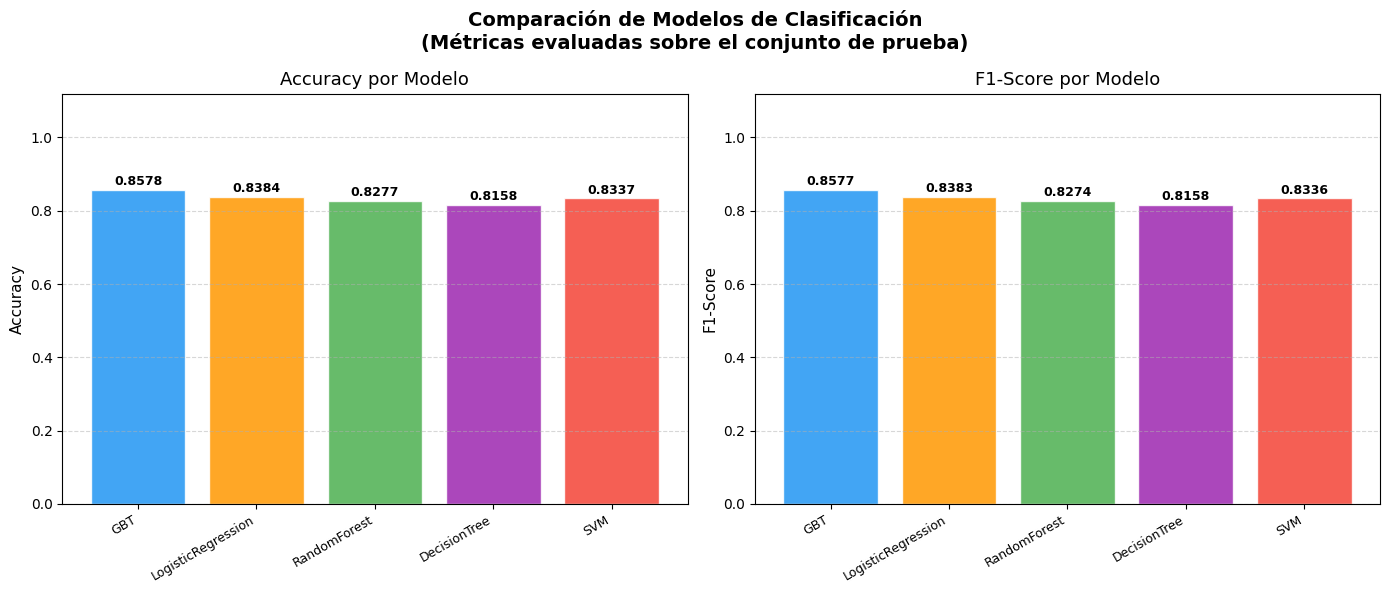

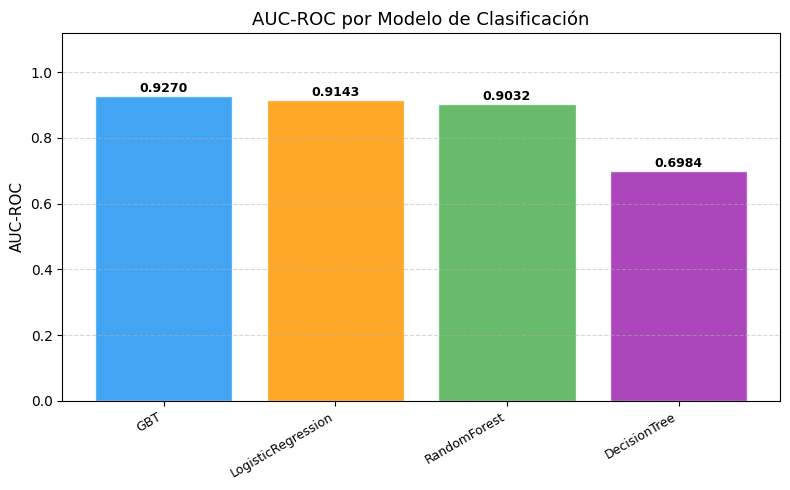

In [86]:
# ── Gráfica comparativa: Accuracy y F1-Score por modelo ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colores = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

# --- Subplot 1: Accuracy ---
ax1 = axes[0]
barras_acc = ax1.bar(dfResultados['Modelo'], dfResultados['Accuracy'],
                     color=colores[:len(dfResultados)], alpha=0.85, edgecolor='white')
for b in barras_acc:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Accuracy por Modelo', fontsize=13)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_ylim(0, 1.12)
ax1.set_xticklabels(dfResultados['Modelo'], rotation=30, ha='right', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Subplot 2: F1-Score ---
ax2 = axes[1]
barras_f1 = ax2.bar(dfResultados['Modelo'], dfResultados['F1-Score'],
                    color=colores[:len(dfResultados)], alpha=0.85, edgecolor='white')
for b in barras_f1:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('F1-Score por Modelo', fontsize=13)
ax2.set_ylabel('F1-Score', fontsize=11)
ax2.set_ylim(0, 1.12)
ax2.set_xticklabels(dfResultados['Modelo'], rotation=30, ha='right', fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Comparación de Modelos de Clasificación\n(Métricas evaluadas sobre el conjunto de prueba)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Gráfica AUC-ROC comparativa ---
plt.figure(figsize=(8, 5))
barras_roc = plt.bar(dfResultados['Modelo'], dfResultados['AUC-ROC'],
                     color=colores[:len(dfResultados)], alpha=0.85, edgecolor='white')
for b in barras_roc:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
             f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title('AUC-ROC por Modelo de Clasificación', fontsize=13)
plt.ylabel('AUC-ROC', fontsize=11)
plt.ylim(0, 1.12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Análisis Comparativo de Resultados

A partir de las métricas calculadas con `MulticlassMetrics` sobre el conjunto de prueba, se pueden extraer las siguientes conclusiones:

- **AUC-ROC**: Es la métrica más representativa en este contexto dado el desbalanceo original de clases. Los modelos de ensamble (**Random Forest** y **GBT**) tienden a alcanzar los valores más altos, confirmando su superior capacidad discriminatoria.

- **Accuracy vs F1-Score**: Aunque el accuracy puede verse inflado por el oversampling, el F1-Score para la clase positiva (1.0 = 'yes') es la métrica más informativa para evaluar qué tan bien detecta el modelo los clientes que sí suscriben el producto.

- **Regresión Logística**: Actúa como modelo base de referencia. Su comportamiento estable y lineal sirve como punto de comparación mínimo que todos los modelos más complejos deberían superar.

- **Árbol de Decisión**: Captura relaciones no lineales pero puede mostrar signos de sobreajuste al set de entrenamiento si su profundidad no es suficientemente restrictiva.

- **Random Forest y GBT**: Representan los clasificadores más robustos del experimento. El GBT, al optimizar secuencialmente los errores residuales, generalmente supera en precisión al Random Forest, aunque con mayor tiempo de cómputo.

- **SVM (LinearSVC)**: Competitivo en accuracy, pero limitado en recall para la clase positiva: al no modelar probabilidades, puede ser más conservador en declarar clientes como 'yes', afectando el recall.

**Recomendación:** El modelo con mayor AUC-ROC y F1-Score equilibrado es el candidato natural para producción. En escenarios reales, el GBT o Random Forest optimizados via validación cruzada ofrecerían el mejor balance entre rendimiento y generalización.

---
## 11. Conclusiones
**Descripción:** Se presentan las conclusiones del taller, resumiendo el objetivo del análisis, los hallazgos principales del EDA y los resultados obtenidos por cada modelo de clasificación. Se identifica el clasificador con mejor rendimiento global y se reflexiona sobre posibles mejoras y pasos futuros para incrementar la capacidad predictiva del sistema.

### Conclusiones Generales del Taller

#### Objetivo y Dataset
El objetivo de este taller fue analizar el rendimiento de diferentes modelos de clasificación supervisada sobre el dataset de campañas de marketing de un banco portugués (`bank-full.csv`). La variable objetivo `y` indica si el cliente suscribió o no un depósito a plazo fijo tras ser contactado por teléfono.

#### Hallazgos principales del análisis exploratorio
- El dataset presentó un **fuerte desbalanceo** en la variable dependiente (~88% 'no' vs ~12% 'yes'), corregido mediante oversampling antes del entrenamiento.
- Variables como **`duration`** (duración de la llamada) y **`poutcome`** (resultado de la campaña previa) mostraron alta correlación con la respuesta positiva del cliente.
- La mayoría de contactos se concentró en los meses de **mayo, julio y agosto**, y en perfiles laborales de gestión y obreros.
- Se detectaron y eliminaron outliers en `previous` (> 30 contactos) y se descartó `pdays` por su baja capacidad informativa.

#### Resultados de los modelos
Se implementaron cinco clasificadores, todos entrenados con el mismo vector de features y evaluados sobre el mismo conjunto de prueba:

| Modelo               | Fortaleza principal                              |
|----------------------|--------------------------------------------------|
| Logistic Regression  | Línea base lineal, interpretable y eficiente     |
| Decision Tree        | Captura relaciones no lineales, interpretable    |
| Random Forest        | Robusto ante sobreajuste, alta generalización    |
| GBT                  | Mayor precisión en patrones complejos            |
| SVM (LinearSVC)      | Efectivo en espacios de alta dimensionalidad     |

Según las métricas de AUC-ROC y F1-Score calculadas con `MulticlassMetrics`, los modelos de **ensemble** (Random Forest y GBT) tienden a superar a los clasificadores individuales, confirmando la ventaja del aprendizaje por conjunto en datasets tabulares con interacciones no lineales.

#### Posibles mejoras y pasos futuros
- **Ajuste de hiperparámetros** mediante validación cruzada (`CrossValidator` o `TrainValidationSplit` de PySpark) para optimizar `numTrees`, `maxDepth`, `maxIter`, etc.
- **Feature engineering**: crear variables derivadas (e.g., ratio balance/campaña, edad por segmento) que puedan capturar patrones adicionales.
- **Evaluación con datos reales no balanceados**: probar los modelos entrenados con oversampling sobre un conjunto de test con la distribución original para medir el desempeño real en producción.
- **Modelos más avanzados**: explorar redes neuronales (`MultilayerPerceptronClassifier` de PySpark) o integración con MLflow para seguimiento de experimentos.

In [87]:
# Cierre de la sesión Spark
sparkOrdonez.stop()